
<table width="100%">
  <td style="font-size:40px;text-align:left;background-color:rgba(142, 179, 255, 0.7);font-style:italic;">
    <b>Final practice.</b> QML for High Energy Physics (HEP).<br>
    <span style="font-size:35px;font-style:normal;">
      Borja Álvarez Reguera.
    </span>
  </td>
</table>

# Introduction and motivation.
The characterization of the Higgs boson’s coupling to the top quark—the most massive fundamental particle in the Standard Model (SM)—represents a cornerstone of the Large Hadron Collider (LHC) physics program. Specifically, the production of a Higgs boson in association with a top-antitop pair ($t\bar{t}H$) provides a direct probe into the top-quark Yukawa coupling, $y_t$, which is essential for validating the mechanism of electroweak symmetry breaking. However, **isolating the $\mathbf{t\bar{t}H}$ signal is an arduous task due to its extremely low cross-section and the presence of overwhelming irreducible backgrounds from other SM processes**. Traditional Multivariate Analysis (MVA) techniques, while robust, often struggle to capture the intricate, non-linear correlations inherent in high-dimensional HEP datasets, particularly when the signal-to-background ratio is unfavorable.

This research explores the paradigm shift toward Quantum Machine Learning (QML) as a potential solution to these classical limitations. By leveraging the principles of superposition and entanglement, Quantum Classifiers—specifically Quantum Support Vector Classifiers (QSVC) and Variational Quantum Classifiers (VQC)—can map classical features into a high-dimensional Hilbert space where linear separation might be more achievable. Our study evaluates twelve distinct models, ranging from classical benchmarks like Grid-Search SVMs and Deep Neural Networks to sophisticated quantum architectures using $Z$, $ZZ$, and Pauli-Feature Maps. By conducting a dual-stage analysis via PCA-3 sensitivity studies and PCA-80% scale studies, we aim to identify the "quantum advantage" threshold and determine how variational circuit depth and entanglement topology influence the classification landscape in the search for New Physics.

## Enviroment and dependencies.
The computational pipeline for this study integrates classical high-performance libraries with specialized quantum frameworks to ensure a seamless end-to-end workflow. Data ingestion is handled via `uproot`, facilitating the direct interface between Python and the ROOT file format standard in High Energy Physics (HEP). The classical machine learning stack relies on `Scikit-Learn` for preprocessing and dimensionality reduction (PCA), while `TensorFlow` provides the backend for multilayer perceptron (MLP) architectures.

The quantum component is powered by the `Qiskit` ecosystem, specifically utilizing `qiskit-machine-learning` for the implementation of Kernel-based methods and Variational Quantum Classifiers (VQCs). To maintain a clean experimental environment, rigorous logging suppression is applied to ensure that stochastic optimization outputs and deprecation warnings do not obscure critical performance metrics. This hybrid stack is designed to support the transition from classical feature engineering to quantum feature mapping and circuit execution.

In [1]:
# =============================
# Enviroment and dependencies
# =============================

# --- Auto-install missing packages ---
import sys
import subprocess

# Only uproot is considered potentially missing based on environment specs
try:
    import uproot
except ImportError:
    print("--> Status: 'uproot' not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "uproot"])
    import uproot

# --- Suppress TensorFlow and Keras noise ---
import os, logging, warnings

# Set level 3 to suppress info and warning logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
# Filter out specific user and deprecation warnings
warnings.filterwarnings('ignore', category=UserWarning, module='keras')
warnings.filterwarnings('ignore', category=DeprecationWarning)
# Silence the tensorflow logger
logging.getLogger('tensorflow').setLevel(logging.ERROR)
# Silence Qiskit warnings
logging.getLogger("qiskit").setLevel(logging.ERROR)
logging.getLogger("qiskit_machine_learning").setLevel(logging.ERROR)
logging.getLogger("qiskit_algorithms").setLevel(logging.ERROR)

# --- Classical Python Packages ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd
import seaborn as sns
import time, pickle, json, tarfile, urllib.request
from typing import Literal, Optional

# --- Machine Learning Tools (Classical) ---
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (f1_score, accuracy_score, precision_score, 
                             recall_score, roc_auc_score, roc_curve, 
                             auc, confusion_matrix, classification_report)
from sklearn.svm import SVC

# --- Deep Learning (Classical - Keras/TF) ---
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Qiskit and Quantum Machine Learning ---
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.algorithms import QSVC, VQC
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import ZFeatureMap, ZZFeatureMap, PauliFeatureMap, RealAmplitudes, EfficientSU2
from qiskit_algorithms.optimizers import COBYLA

## Data visualization and global aesthetics.
To ensure consistency and interpretability across the Exploratory Data Analysis (EDA) and model evaluation phases, this section establishes a **unified visual framework and custom plotting utilities**. By defining a global style dictionary, we standardize thematic elements such as probability density scaling, color palettes—optimized for signal-background contrast—and font hierarchies. The implemented functions, `plot_feature_distribution` and `plot_feature_pair_plot`, automate the generation of normalized histograms and multi-dimensional interaction maps (KDE and scatter matrices). These tools are specifically tailored to highlight the separation of the $t\bar{t}H$ signal from SM noise, allowing for a preliminary qualitative assessment of feature importance and the non-linear correlations that quantum kernels are hypothesized to exploit.

In [2]:
# ==========================================
# Global style and data plotting utilities
# ==========================================

# --- Global style dictionary ---
style = {
    "cmap_name": "Blues",
    "facecolor": plt.get_cmap("Blues")(0.05),
    "grid_color": plt.get_cmap("Blues")(0.3),
    "main_color": plt.get_cmap("Blues")(0.8),
    "ref_color": plt.get_cmap("Blues")(0.4),
    "bar_color": plt.get_cmap("Blues")(0.6),
    "bar_edge": plt.get_cmap("Blues")(0.9),
    "title_size": 20,
    "label_size": 18,
    "tick_size": 16,
    "line_width": 4,
    "grid_alpha": 0.7,
    "font_weight": "bold"
}

# --- Feature histogram plot ---
def plot_feature_distribution(df, feature_name, x_label=None, bins=50):
    """
    Plots the distribution of a feature for signal and background 
    using the project's global style configuration.
    """
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    ax.set_facecolor(style["facecolor"])

    # Set spines thickness and color
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color(style["bar_edge"])

    # Separate data based on target
    sig_data = df[df['target'] == 1][feature_name]
    bkg_data = df[df['target'] == 0][feature_name]

    # Plot histograms
    plt.hist(sig_data, bins=bins, alpha=0.7, density=True, 
             color=style["main_color"], label='Signal', 
             edgecolor=style["main_color"], lw=2, histtype='stepfilled')
    
    plt.hist(bkg_data, bins=bins, alpha=0.4, density=True, 
             color=style["ref_color"], label='Background', 
             edgecolor=style["ref_color"], lw=2, histtype='stepfilled', hatch='//')

    # Formatting using the global style dictionary
    plt.title(f"Distribution of {feature_name}", fontsize=style["title_size"], 
              fontweight=style["font_weight"], pad=20)
    
    # Custom or default x-axis label
    actual_label = x_label if x_label else feature_name
    plt.xlabel(actual_label, fontsize=style["label_size"], fontweight=style["font_weight"])
    plt.ylabel("Probability Density", fontsize=style["label_size"], fontweight=style["font_weight"])
    
    # Grid and Ticks
    plt.grid(True, linestyle="--", alpha=style["grid_alpha"], color=style["grid_color"])
    plt.tick_params(axis='both', labelsize=style["tick_size"])
    
    # Legend with matched facecolor and edgecolor
    legend = plt.legend(fontsize=style["tick_size"], frameon=True)
    legend_frame = legend.get_frame()
    legend_frame.set_facecolor(style["facecolor"])
    legend_frame.set_edgecolor(style["bar_edge"])
    legend_frame.set_linewidth(2)
    
    plt.show()

# --- Pair plot ---
def plot_feature_pair_plot(df: pd.DataFrame, features: list, target_col: str = 'target'):
    """
    Generates a symmetric pair plot with scatter plots in off-diagonals and clean 
    KDEs on the diagonal. Labels classes as Background/Signal with high-readability settings.
    """
    sns.set_theme(style="white")
    
    # Map numeric targets to descriptive labels
    plot_df = df.copy()
    plot_df[target_col] = plot_df[target_col].map({0: "Background", 1: "Signal"})

    # Initialize Grid
    g = sns.PairGrid(plot_df, vars=features, hue=target_col, 
                     palette=[style["ref_color"], style["main_color"]],
                     diag_sharey=False)

    # 1. Diagonal: KDE Plots
    g.map_diag(sns.kdeplot, fill=True, alpha=0.5, lw=style["line_width"]//2)

    # 2. Off-Diagonal: Scatter Plots with transparency
    g.map_offdiag(sns.scatterplot, alpha=0.4, s=40, edgecolor=style["bar_edge"], linewidth=0.5)

    # 3. Global Styling
    for i, j in zip(*np.triu_indices_from(g.axes, k=0)):
        for ax in [g.axes[i, j], g.axes[j, i]]:
            if ax is None: continue
            ax.set_facecolor(style["facecolor"])
            
            for spine in ax.spines.values():
                spine.set_linewidth(2)
                spine.set_color(style["bar_edge"])
            
            ax.grid(True, linestyle="--", alpha=style["grid_alpha"], color=style["grid_color"])
            ax.tick_params(axis='both', labelsize=style["tick_size"] - 4)

    # Label styling
    for ax in g.axes.flatten():
        if ax.get_xlabel():
            ax.xaxis.label.set_size(style["label_size"] - 2)
            ax.xaxis.label.set_weight(style["font_weight"])
        if ax.get_ylabel():
            ax.yaxis.label.set_size(style["label_size"] - 2)
            ax.yaxis.label.set_weight(style["font_weight"])

    g.fig.suptitle("Feature Interaction Map", fontsize=style["title_size"], 
                   fontweight=style["font_weight"], y=1.02)
    
    # 4. Robust Legend Customization
    g.add_legend(title="Class", adjust_subtitles=True)
    legend = g._legend
    legend.get_title().set_fontsize(style["label_size"])
    legend.get_title().set_weight(style["font_weight"])
    
    for text in legend.get_texts():
        text.set_fontsize(style["label_size"] - 2)
        text.set_fontweight(style["font_weight"])
    
    # Check handle type before setting size/width
    for handle in legend.legend_handles:
        handle.set_alpha(1.0)
        if hasattr(handle, 'set_sizes'):
            handle.set_sizes([200]) # For scatter-like markers
        if hasattr(handle, 'set_linewidth'):
            handle.set_linewidth(style["line_width"]) # For line-like markers
            
    g.fig.subplots_adjust(right=0.82, top=.97, wspace=0.2, hspace=0.2)
    g._legend.set_bbox_to_anchor((0.98, 0.5))
    plt.show()

## Performance evaluation and statistical metrics.

The validation of classifiers in HEP requires a multi-dimensional approach that extends beyond standard accuracy. This module implements `compute_metrics`, a specialized function that calculates the Receiver Operating Characteristic Area Under the Curve (ROC AUC) and $F_1$ scores, alongside HEP-specific indicators such as Purity and Statistical Significance. To visualize these results, the `plot_model_performance` dashboard generates a three-panel report containing the ROC curve to assess discriminative power, a normalized confusion matrix to identify class-specific misclassifications, and a consolidated bar chart for cross-model benchmarking. Furthermore, the `plot_training_history` utility provides a unified interface to monitor loss convergence across both classical `TensorFlow` epochs and quantum `COBYLA` iterations, ensuring a rigorous comparison of the learning dynamics between traditional optimization and variational quantum circuits.

In [3]:
# ====================================
# Performance evaluation and metrics
# ====================================

# --- Metrics ---
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray, training_time: float) -> dict:
    """Calculates performance metrics including HEP-specific indicators."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec_pos = recall_score(y_true, y_pred, pos_label=1) 
    rec_neg = recall_score(y_true, y_pred, pos_label=0) 
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_score) if y_score is not None else 0.0
    
    cm = confusion_matrix(y_true, y_pred)
    tp, fp = cm[1, 1], cm[0, 1]
    significance = tp / np.sqrt(tp + fp) if (tp + fp) > 0 else 0.0
    purity = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    return {
        "accuracy": acc, "precision": prec, "recall_positive": rec_pos,
        "recall_negative": rec_neg, "f1": f1, "roc_auc": roc_auc,
        "purity": purity, "significance": significance, "training_time_sec": training_time
    }

# --- Comparative plot ---
def plot_model_performance(metrics: dict, y_test: np.ndarray, y_pred: np.ndarray, 
                           y_score: np.ndarray = None, title_prefix: str = "Model"):
    """Generalized dashboard consuming the global style configuration."""
    sns.set_theme(style="white") 
    fig = plt.figure(figsize=(14, 10), layout="constrained")
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])
    cmap = plt.get_cmap(style["cmap_name"])

    # --- 1. ROC Curve ---
    ax_roc = fig.add_subplot(gs[0, 0])
    ax_roc.set_facecolor(style["facecolor"])
        # Set spines (axes lines) thickness and color
    for spine in ax_roc.spines.values():
        spine.set_linewidth(2)
        spine.set_color(style["bar_edge"])
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_test, y_score)
        ax_roc.plot([0, 1], [0, 1], "--", color=style["ref_color"], lw=2)
        ax_roc.plot(fpr, tpr, lw=style["line_width"], color=style["main_color"]) 
        ax_roc.set_title(f"{title_prefix} ROC Curve", fontsize=style["title_size"], fontweight=style["font_weight"], pad=20)
        ax_roc.set_xlabel("False Positive Rate", fontsize=style["label_size"], fontweight=style["font_weight"])
        ax_roc.set_ylabel("True Positive Rate", fontsize=style["label_size"], fontweight=style["font_weight"])
        ax_roc.tick_params(axis='both', labelsize=style["tick_size"])
        ax_roc.grid(True, linestyle="--", alpha=style["grid_alpha"], color=style["grid_color"])

    # --- 2. Confusion Matrix ---
    ax_cm = fig.add_subplot(gs[0, 1])
    cm = confusion_matrix(y_test, y_pred)
    cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    for spine in ax_cm.spines.values():
        spine.set_linewidth(2)
        spine.set_color(style["bar_edge"])
    ax_cm.imshow(cm_percent, cmap=cmap, interpolation='nearest')
    ax_cm.set_title(f"{title_prefix} Confusion Matrix", fontsize=style["title_size"], fontweight=style["font_weight"], pad=20)
    ax_cm.set_xticks([0, 1]); ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(["Background", "Signal"], fontsize=style["tick_size"], fontweight=style["font_weight"])
    ax_cm.set_yticklabels(["Background", "Signal"], fontsize=style["tick_size"], fontweight="bold")
    ax_cm.set_xlabel("Predicted label", fontsize=style["label_size"], fontweight=style["font_weight"])
    ax_cm.set_ylabel("True label", fontsize=style["label_size"], fontweight=style["font_weight"])
    for i, j in [(0,0), (0,1), (1,0), (1,1)]:
        color = "white" if cm_percent[i, j] > 50 else "black"
        ax_cm.text(j, i, f"{cm_percent[i, j]:.1f}%\n(n={cm[i,j]})", ha="center", va="center", 
                   fontsize=style["label_size"], fontweight=style["font_weight"], color=color)

    # --- 3. Performance Summary (Normalized Metrics) ---
    ax_bar = fig.add_subplot(gs[1, :])
    ax_bar.set_facecolor(style["facecolor"])
    
    for spine in ax_bar.spines.values():
        spine.set_linewidth(2)
        spine.set_color(style["bar_edge"])
        
    m_keys = ["accuracy", "precision", "recall_positive", "recall_negative", "f1", "roc_auc", "purity"]
    names = ["Accuracy", "Precision", "Recall (+)", "Recall (-)", "F1 Score", "ROC AUC", "Purity"]
    values = [metrics.get(k, 0.0) for k in m_keys]
    
    bars = ax_bar.bar(names, values, width=0.6, color=style["bar_color"], edgecolor=style["bar_edge"], alpha=0.8, lw=2)
    ax_bar.set_ylim(0, 1.15)
    ax_bar.set_title(f"{title_prefix} Performance Summary", fontsize=style["title_size"], fontweight=style["font_weight"], pad=20)
    ax_bar.set_xticks(range(len(names))); ax_bar.set_xticklabels(names, fontsize=style["tick_size"]-2, fontweight=style["font_weight"])
    ax_bar.grid(axis="y", linestyle="--", alpha=style["grid_alpha"], color=style["grid_color"])
    for bar in bars:
        ax_bar.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, 
                    f"{bar.get_height():.3f}", ha="center", fontweight=style["font_weight"], fontsize=style["tick_size"]-2)
    plt.show()

# --- History plot ---
def plot_training_history(history_data, title_prefix: str = "Model"):
    """Visualizes loss evolution using the same global style configuration."""
    if history_data is None:
        return

    plt.figure(figsize=(14, 6))
    ax = plt.gca()
    ax.set_facecolor(style["facecolor"])
    
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color(style["bar_edge"])
    
    # Check data type to extract losses correctly
    if isinstance(history_data, list): # Quantum Case
        plt.plot(history_data, color=style["main_color"], lw=style["line_width"], label="Training Loss (Quantum)")
        plt.xlabel("Iterations", fontsize=style["label_size"], fontweight=style["font_weight"])
        
    else: # Classical Case (Live object or Cached dictionary)
        # Use .history if it's a Keras object, otherwise treat as a dictionary
        h_dict = history_data.history if hasattr(history_data, 'history') else history_data
        
        if 'loss' in h_dict:
            plt.plot(h_dict['loss'], color=style["main_color"], lw=style["line_width"], label="Train Loss")
        if 'val_loss' in h_dict:
            plt.plot(h_dict['val_loss'], color=style["ref_color"], lw=style["line_width"], ls="--", label="Val Loss")
        
        plt.xlabel("Epochs", fontsize=style["label_size"], fontweight=style["font_weight"])

    plt.title(f"{title_prefix} Convergence History", fontsize=style["title_size"], fontweight=style["font_weight"], pad=20)
    plt.ylabel("Loss Value", fontsize=style["label_size"], fontweight=style["font_weight"])
    plt.grid(True, linestyle="--", alpha=style["grid_alpha"], color=style["grid_color"])
    plt.tick_params(axis='both', labelsize=style["tick_size"])
    
    # Safety check for legend
    if ax.get_legend_handles_labels()[0]:
        plt.legend(edgecolor=style["bar_edge"], facecolor=style["facecolor"], 
                   fontsize=style["tick_size"], frameon=True).get_frame().set_linewidth(2)
    
    plt.show()

## Persistence and experiment storage engine.

This module implements a structured serialization strategy to manage the diverse artifacts generated during the process. The `generate_experiment_id` function creates unique, descriptive identifiers by encoding key parameters—such as PCA dimensionality and circuit topology—into sanitized strings for systematic tracking. To address serialization constraints within `Qiskit`, the `save_experiment_results` and `load_experiment_results` functions utilize a dual-path logic: while classical models use `pickle` or `Keras` formats, quantum architectures like VQC and QSVC are preserved via raw `NumPy` weight arrays and metadata. **This ensures high-fidelity reproduction of results** and facilitates comparative analysis without the computational overhead of re-calculating quantum kernels or variational gradients.

In [4]:
# ================================
# Persistence and storage engine
# ================================

def generate_experiment_id(model_type: str, params: dict) -> str:
    """
    Constructs a descriptive, filesystem-safe ID for HEP-QML experiments.
    Updated to handle dynamic Quantum Feature Maps and Ansatz types.
    """
    quantum_models = ["VQC", "QSVM", "QNN"]
    category = "QUAN" if model_type.upper() in quantum_models else "CLAS"
    
    # Expanded alias dictionary for Quantum variability
    alias = {
        "pca_dim": "PCA", 
        "feature_dimension": "PCA", 
        "entanglement": "Ent", 
        "feature_map_type": "FM",
        "ansatz_type": "Ans",
        "reps_fm": "FMReps", 
        "reps_ansatz": "AnsReps", 
        "reps": "CycReps", 
        "c_param": "C", 
        "C": "C", 
        "learning_rate": "Rate", 
        "kernel_name": "Kern", 
        "hidden_layers": "Arch", 
        "max_iter": "Iter"
    }
    
    dim_val = params.get("pca_dim") or params.get("feature_dimension") or "NA"
    id_parts = [f"{category}_{model_type.upper()}_PCA{dim_val}"]

    # Sorted keys ensure consistent ID generation regardless of dictionary order
    for key in sorted(params.keys()):
        if key in ["pca_dim", "feature_dimension"]: continue
        
        val = params[key]
        prefix = alias.get(key, key[:3].capitalize())
        
        # Format values: floats replace '.' with 'p', lists use 'x' separator
        if isinstance(val, list):
            formatted_val = "x".join(map(str, val))
        elif isinstance(val, float):
            formatted_val = f"{val:g}".replace(".", "p")
        else:
            formatted_val = str(val)

        # Sanitize for filesystem safety
        clean_val = formatted_val.replace("[", "").replace("]", "").replace(" ", "").replace("'", "")
        id_parts.append(f"{prefix}-{clean_val}")

    return "_".join(id_parts)

def save_experiment_results(model, metrics: dict, params: dict, 
                            y_pred: np.ndarray, y_score: np.ndarray, 
                            experiment_id: str, history=None):
    """
    Persists model artifacts including weights for quantum models to avoid 
    pickle serialization errors with local Qiskit functions.
    """
    base_dir = "saved_experiments"
    for sub in ["models", "metrics", "predictions", "configs", "histories"]:
        os.makedirs(os.path.join(base_dir, sub), exist_ok=True)

    model_path = os.path.join(base_dir, "models", experiment_id)
    
    # 1. Specialized saving for Quantum VQC/QNN
    if "VQC" in str(type(model)) or "QNN" in str(type(model)):
        try:
            # Save weights (NumPy array) and circuit params separately
            if hasattr(model, 'weights'):
                np.save(f"{model_path}_weights.npy", model.weights)
            # We save a marker to know it's a quantum model during load
            with open(f"{model_path}_qtype.txt", "w") as f:
                f.write(str(type(model)))
        except Exception as e:
            print(f"[Warning] Failed to save quantum weights: {e}")
            
    # Standard saving for Classical/Keras models
    elif hasattr(model, "save") and "keras" in str(type(model)).lower():
        model.save(f"{model_path}.keras")
    else:
        try:
            with open(f"{model_path}.pkl", "wb") as f:
                pickle.dump(model, f)
        except Exception as e:
            print(f"[Warning] Pickle failed for model object: {e}")

    # 2. Save training history
    if history is not None:
        history_path = os.path.join(base_dir, "histories", f"{experiment_id}_hist.pkl")
        h_data = history.history if hasattr(history, 'history') else history
        with open(history_path, "wb") as f:
            pickle.dump(h_data, f)

    # 3. Save metadata & predictions
    with open(os.path.join(base_dir, "metrics", f"{experiment_id}.json"), "w") as f:
        json.dump(metrics, f, indent=4)
    with open(os.path.join(base_dir, "configs", f"{experiment_id}.json"), "w") as f:
        json.dump(params, f, indent=4)
    with open(os.path.join(base_dir, "predictions", f"{experiment_id}_preds.pkl"), "wb") as f:
        pickle.dump({"y_pred": y_pred, "y_score": y_score}, f)
        
    print(f"[Storage] Experiment '{experiment_id}' successfully cached.")

def load_experiment_results(experiment_id: str):
    """
    Retrieves assets. Handles the special case of quantum models where 
    only weights might be available due to serialization constraints.
    """
    base_dir = "saved_experiments"
    metrics_path = os.path.join(base_dir, "metrics", f"{experiment_id}.json")
    preds_path = os.path.join(base_dir, "predictions", f"{experiment_id}_preds.pkl")
    hist_path = os.path.join(base_dir, "histories", f"{experiment_id}_hist.pkl")
    
    if not (os.path.exists(metrics_path) and os.path.exists(preds_path)):
        return None, None, None, None, None

    with open(metrics_path, "r") as f: metrics = json.load(f)
    with open(preds_path, "rb") as f: preds = pickle.load(f)
    
    history = None
    if os.path.exists(hist_path):
        with open(hist_path, "rb") as f: history = pickle.load(f)

    # Load model (handling Keras, Pickle, and Quantum Weights)
    keras_path = os.path.join(base_dir, "models", f"{experiment_id}.keras")
    pickle_path = os.path.join(base_dir, "models", f"{experiment_id}.pkl")
    weights_path = os.path.join(base_dir, "models", f"{experiment_id}_weights.npy")
    
    try:
        model = None
        if os.path.exists(keras_path):
            model = tf.keras.models.load_model(keras_path)
        elif os.path.exists(weights_path):
            # For Quantum: we return the weights array as the 'model' object
            # if the full object couldn't be pickled.
            model = np.load(weights_path)
            print(f"[Storage] Loaded Quantum Weights for '{experiment_id}'.")
        elif os.path.exists(pickle_path):
            with open(pickle_path, "rb") as f: model = pickle.load(f)
        
        if model is not None:
            return model, metrics, preds["y_pred"], preds["y_score"], history
            
        return None, None, None, None, None
        
    except Exception as e:
        print(f"[Storage] Error loading '{experiment_id}': {e}")
        return None, None, None, None, None

## Classical and quantum neural networks trainers.

This module defines the training infrastructure for both the classical Deep Learning benchmarks and the Variational Quantum Classifiers (VQC). The `train_classical_nn` function implements a dynamic Multi-Layer Perceptron (MLP) using `TensorFlow`, featuring `Dropout` layers to emulate the handling of systematic uncertainties and `EarlyStopping` callbacks to prevent overfitting on the $t\bar{t}H$ dataset. Conversely, `train_quantum_vqc` manages the variational pipeline, where classical features are mapped into quantum states using `ZZFeatureMap` or `PauliFeatureMap` before undergoing optimization via the `COBYLA` algorithm. To bridge the gap between these paradigms, a custom `QTrainingLogCallback` is utilized to track the convergence of the quantum cost function, while `MinMaxScaler` ensures that input features are scaled to the $[0, \pi]$ range required for coherent phase encoding in the Hilbert space.

Regarding the tracking of quantum optimization, it should be noted that the current `QTrainingLogCallback` implementation remains non-functional in this specific environment due to signature mismatches with the `VQC` and ``COBYLA`` interfaces. Although this logging mechanism was successfully validated in other notebooks (see practice 1.2 about VQCs in Winsconsin Cancer Dataset), it is preserved here as a conceptual blueprint for real-time monitoring of the variational landscape. Re-establishing full compatibility for this callback is deferred as future work, aiming to enhance the transparency of the quantum learning process without compromising the current stability of the training loop.

In [5]:
# ===============================
# Neural Networks (NN) trainers
# ===============================

# --- Advanced Quantum Callback ---
# THIS DOES NOT WORK, so we can ignore it
class QTrainingLogCallback:
    def __init__(self, print_every=10):
        self.print_every = print_every
        self.iteration = 0
        self.loss_history = []
        self._start_time = time.time()
        self._last_time = time.time()

    def callback(self, *args):
        """
        Flexible callback to handle different Qiskit/SciPy signatures.
        """
        self.iteration += 1
        
        # Depending on who calls, the loss/value is in different positions
        # If called by VQC directly: (weights, loss)
        # If called by COBYLA: (weights) -> we might not have 'value' here
        loss_val = 0.0
        if len(args) >= 2:
            loss_val = args[1]
            self.loss_history.append(float(loss_val))
        
        if self.iteration % self.print_every == 0:
            current_time = time.time()
            elapsed = current_time - self._last_time
            # Show loss only if we captured it
            loss_str = f"Loss: {loss_val:.4f}" if len(args) >= 2 else "Training..."
            print(f"    > [Iter {self.iteration}] {loss_str} | Step: {elapsed:.2f}s")
            self._last_time = current_time

# --- Classical Callback Factory ---
def get_classical_callbacks(patience_stop=20, patience_lr=5):
    """
    Generates a robust set of Keras callbacks for HEP data.
    """
    return [
        # Stop if no improvement to prevent overfitting (critical in physics)
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=patience_stop, restore_best_weights=True, verbose=0
        ),
        # Reduce learning rate if stuck in a local minimum
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-6, verbose=0
        )
    ]

# --- Training Functions ---
def train_classical_nn(X_train: np.ndarray, y_train: np.ndarray,
                       X_test: np.ndarray, y_test: np.ndarray,
                       hidden_layers: list = [64, 32], 
                       epochs: int = 100, batch_size: int = 32, 
                       learning_rate: float = 0.001, **kwargs) -> tuple:
    """
    Flexible Classical NN trainer. Allows dynamic architecture injection via hidden_layers.
    """
    print(f"\n[Classical NN] Initializing Network | Arch: {hidden_layers} | LR: {learning_rate}")
    start_time = time.time()

    # 1. Dynamic Model Construction
    model = models.Sequential()
    model.add(layers.InputLayer(input_shape=(X_train.shape[1],)))
    
    for i, units in enumerate(hidden_layers):
        model.add(layers.Dense(units, activation='relu'))
        # 30% Dropout is standard in HEP to mimic systematic uncertainty handling
        model.add(layers.Dropout(0.3)) 
        
    model.add(layers.Dense(1, activation='sigmoid'))

    # 2. Compilation
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # 3. Training with Callbacks
    print(f"[Classical NN] Fitting model on {len(X_train)} samples (Max Epochs: {epochs})...")
    my_callbacks = get_classical_callbacks()
    
    history = model.fit(
        X_train, y_train, 
        epochs=epochs, 
        batch_size=batch_size, 
        validation_split=0.2, 
        callbacks=my_callbacks, 
        verbose=0
    )
    
    # 4. Evaluation
    print(f"[Classical NN] Inference on {len(X_test)} samples...")
    y_score = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_score > 0.5).astype(int)

    train_time = time.time() - start_time
    metrics = compute_metrics(y_test, y_pred, y_score, train_time)
    
    # Inject final validation loss into metrics for reference
    metrics['val_loss'] = history.history['val_loss'][-1]
    
    print(f"[Classical NN] Done in {train_time:.2f}s. Accuracy: {metrics['accuracy']:.4f}")
    return model, metrics, y_pred, y_score, history

def train_quantum_vqc(X_train: np.ndarray, y_train: np.ndarray,
                      X_test: np.ndarray, y_test: np.ndarray,
                      feature_dimension: int, 
                      feature_map_type: str = "ZZ",
                      ansatz_type: str = "RealAmplitudes",
                      reps_fm: int = 1,
                      reps_ansatz: int = 1,
                      max_iter: int = 100, **kwargs) -> tuple:
    """
    Trains a VQC with dynamic architecture injection and "detailed" progress logging.
    """
    print(f"\n[Quantum VQC] Initialization")
    print(f"    > Config: {feature_map_type}(reps={reps_fm}) + {ansatz_type}(reps={reps_ansatz})")
    start_time = time.time()

    # 1. Scale data to [0, pi]
    q_scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_train_q = q_scaler.fit_transform(X_train)
    X_test_q = q_scaler.transform(X_test)

    # 2. Dynamic Feature Map Selection
    entanglement = kwargs.get('entanglement', 'linear')
    
    if feature_map_type == "ZZ":
        fm = ZZFeatureMap(feature_dimension=feature_dimension, reps=reps_fm, entanglement=entanglement)
    elif feature_map_type == "Pauli":
        fm = PauliFeatureMap(feature_dimension=feature_dimension, reps=reps_fm, paulis=['Z', 'YY'])
    else:
        fm = ZFeatureMap(feature_dimension=feature_dimension, reps=reps_fm)

    # 3. Dynamic Ansatz Selection
    if ansatz_type == "EfficientSU2":
        ansatz = EfficientSU2(num_qubits=feature_dimension, reps=reps_ansatz, entanglement=entanglement)
    else:
        ansatz = RealAmplitudes(num_qubits=feature_dimension, reps=reps_ansatz, entanglement=entanglement)
        
    # 4. Training setup
    monitor = QTrainingLogCallback(print_every=max(1, max_iter // 10))
    
    vqc = VQC(
        feature_map=fm,
        ansatz=ansatz,
        optimizer=COBYLA(maxiter=max_iter),
        callback=monitor.callback,
        sampler=Sampler()
    )

    y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
    
    print(f"[Quantum VQC] Starting variational optimization (Max Iter: {max_iter})...")
    vqc.fit(X_train_q, y_train_np)
    
    # 5. Execution Summary and Predictions
    train_time = time.time() - start_time
    final_loss = monitor.loss_history[-1] if monitor.loss_history else "N/A"
    
    print(f"[Quantum VQC] Optimization complete in {train_time:.2f} seconds.")

    y_pred = vqc.predict(X_test_q)
    y_score = vqc.predict_proba(X_test_q)[:, 1]

    metrics = compute_metrics(y_test, y_pred, y_score, train_time)
    
    return vqc, metrics, y_pred, y_score, monitor.loss_history

## Classical and quantum Support Vector Machines (SVM).

This section implements the Kernel-based learning architectures, contrasting the classical Support Vector Classifier (SVC) with its Quantum counterpart (QSVC). The `train_classical_svm` function serves as a performance ceiling benchmark, utilizing traditional kernels like Radial Basis Function (`rbf`) and optimizing the regularization parameter $C$. In parallel, the `train_quantum_svm` function leverages the `FidelityQuantumKernel` to compute the similarity between HEP events in a high-dimensional Hilbert space. This quantum approach utilizes the `ComputeUncompute` fidelity estimation via the `Sampler` primitive, mapping the input features through $Z$, $ZZ$, or Pauli feature maps. To ensure metric consistency during evaluation, the quantum decision scores are normalized to a $[0, 1]$ range, allowing for a direct comparison of ROC curves against classical benchmarks.

In [6]:
# ========================================
# Support Vector Machines (SVM) trainers
# ========================================

def train_classical_svm(X_train, y_train, X_test, y_test, kernel_name='rbf', c_param=1.0, **kwargs):
    """Classical SVM Wrapper with standard logging."""
    print(f"\n[Classical SVM] Fitting | Kernel: {kernel_name.upper()} | C: {c_param}")
    start = time.time()
    
    model = SVC(kernel=kernel_name, C=c_param, probability=True, **kwargs)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]
    
    dt = time.time() - start
    print(f"[Classical SVM] Done in {dt:.2f}s.")
    return model, compute_metrics(y_test, y_pred, y_score, dt), y_pred, y_score, None

def train_quantum_svm(X_train, y_train, X_test, y_test, 
                      feature_dimension: int, 
                      kernel_name: str = "ZZFeatureMap", 
                      reps: int = 1, 
                      c_param: float = 1.0, **kwargs) -> tuple:
    """
    Trains a QSVC using a Quantum Kernel with normalized decision scores.
    """
    print(f"\n[Quantum QSVM] Setup | Kernel: {kernel_name} | C: {c_param}")
    start = time.time()

    # 1. Scale data to [0, pi]
    q_scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_train_q = q_scaler.fit_transform(X_train)
    X_test_q = q_scaler.transform(X_test)

    # 2. Dynamic Feature Map for the Kernel
    if kernel_name == "ZFeatureMap":
        fm = ZFeatureMap(feature_dimension=feature_dimension, reps=reps)
    elif kernel_name == "PauliFeatureMap":
        fm = PauliFeatureMap(feature_dimension=feature_dimension, reps=reps, paulis=['Z', 'YY'])
    else:
        fm = ZZFeatureMap(feature_dimension=feature_dimension, reps=reps, entanglement='linear')

    # 3. Fidelity Kernel with Sampler Primitive
    q_kernel = FidelityQuantumKernel(
        fidelity=ComputeUncompute(Sampler()), 
        feature_map=fm
    )
    qsvc = QSVC(quantum_kernel=q_kernel, C=c_param)
    
    y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
    
    print(f"[Quantum QSVM] Computing Quantum Kernel matrix and fitting...")
    qsvc.fit(X_train_q, y_train_np)

    # 4. Predict and normalize scores for ROC/AUC consistency
    y_pred = qsvc.predict(X_test_q)
    raw_scores = qsvc.decision_function(X_test_q)
    
    # Min-Max normalization to ensure y_score is in [0, 1] for metrics
    if raw_scores.max() != raw_scores.min():
        y_score = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
    else:
        y_score = raw_scores

    dt = time.time() - start
    print(f"[Quantum QSVM] Completed in {dt:.2f}s.")
    return qsvc, compute_metrics(y_test, y_pred, y_score, dt), y_pred, y_score, None

## Unified experiment orchestration.

The final component of the auxiliary framework is an unified experiment controller, which **standardizes the execution flow for the entire benchmarking suite**. Through the `train_model_dispatcher`, the system implements a polymorphic interface that dynamically routes hyperparameters to the appropriate classical or quantum trainer based on the model_type specification. This is encapsulated within the `run_experiment` function, an orchestrator designed to handle the full lifecycle of a $t\bar{t}H$ classification task—from automatic feature dimension injection to persistence management. By integrating a "cache-first" logic, the controller verifies the existence of previous results via `load_experiment_results` before triggering new training sessions, ensuring computational efficiency and providing a fail-safe environment for large-scale comparative studies in the quantum-classical hybrid landscape.

In [7]:
# ===============================
# Unified experiment controller
# ===============================

def train_model_dispatcher(X_train, y_train, X_test, y_test, model_type, **kwargs):
    """
    Unified entry point. Distributes kwargs dynamically to the correct trainer.
    Expects all trainers to consistently return a 5-element tuple:
    (model, metrics, y_pred, y_score, history)
    """
    dispatch_map = {
        "NN": train_classical_nn,
        "SVM": train_classical_svm,
        "QNN": train_quantum_vqc,
        "QSVM": train_quantum_svm
    }
    
    if model_type not in dispatch_map:
        raise ValueError(f"Unknown model type: {model_type}. Options: {list(dispatch_map.keys())}")
        
    # Standardized execution: consistency is handled at the trainer level
    return dispatch_map[model_type](X_train, y_train, X_test, y_test, **kwargs)

def run_experiment(X_train, y_train, X_test, y_test, model_type, 
                   force_train=False, skip_save=False, verbose=True, **params):
    """
    Orchestrates the training, evaluation, and persistence of HEP experiments.
    Ensures 'feature_dimension' is injected for quantum models if missing.
    """
    # Auto-inject feature dimension from data if not explicitly provided
    if "feature_dimension" not in params and "pca_dim" in params:
        params["feature_dimension"] = params["pca_dim"]
    elif "feature_dimension" not in params:
        params["feature_dimension"] = X_train.shape[1]

    exp_id = generate_experiment_id(model_type, params)
    
    if not force_train:
        model, metrics, y_pred, y_score, history = load_experiment_results(exp_id)
        if model is not None:
            if verbose: print(f"[Cache] Valid experiment found. Loading: {exp_id}")
            return model, metrics, y_pred, y_score, history

    if verbose:
        print(f"\n{'='*60}")
        print(f"Experiment Start: {exp_id}")
        print(f"{'='*60}")

    try:
        # Standardized call to the dispatcher
        result = train_model_dispatcher(X_train, y_train, X_test, y_test, model_type, **params)
        
        # Safe unpacking: Trainers must return (model, metrics, y_pred, y_score, history)
        model, metrics, y_pred, y_score, history = result

        if not skip_save:
            save_experiment_results(model, metrics, params, y_pred, y_score, exp_id, history)
        elif verbose:
            print(f"[Storage] 'skip_save' is active. Results will not be cached.")

        return model, metrics, y_pred, y_score, history

    except Exception as e:
        print(f"[Error] Experiment {exp_id} failed: {str(e)}")
        raise e

# Data acquisition and preprocessing.

The dataset for this study comprises simulated events tailored to the high-luminosity conditions of the LHC. We focus on the multilepton final state, a signature characterized by the presence of three or more prompt leptons ($e^\pm, \mu^\pm$). This channel is particularly significant for measuring the $t\bar{t}H$ process, as it offers a cleaner signal-to-background ratio compared to fully hadronic channels, albeit at the cost of a lower branching ratio. The signal of interest is the production of a Higgs boson in association with a top-antitop quark pair ($t\bar{t}H$), which provides a direct measurement of the top-quark Yukawa coupling, $y_t$.

To evaluate the discriminative power of our models, **the signal is compared against two critical SM backgrounds**. The $t\bar{t}W$ production serves as an irreducible background, sharing similar final-state topologies with multiple b-jets and prompt leptons, making it the primary bottleneck for $t\bar{t}H$ sensitivity. In contrast, Drell-Yan production ($pp\to Z/\gamma^*$ + jets) represents a reducible but high-statistics background where leptons originate from vector boson decays. The classification challenge lies in the subtle kinematic differences—such as the missing transverse energy $\left(\text{E}_{\text{T}}^{\text{miss}}\right)$ and the angular correlations between leptons—which define a non-trivial manifold in the phase space. Effectively separating these processes requires the capture of high-order correlations, providing a rigorous testbed for the feature-mapping capabilities of both Deep Learning and Quantum kernels.

## Data ingestion and cleaning.

This section automates the acquisition and conversion of raw HEP data into a structured format suitable for machine learning. We utilize the ``urllib`` and ``tarfile`` libraries to retrieve the dataset from a remote repository, ensuring the workspace is initialized with the necessary ``.root`` files. The core of the ingestion process relies on the ``uproot`` library, which enables high-performance reading of TTree structures without a full ROOT installation. By implementing the ``load_tree`` wrapper, we map the 'Friends' trees from the signal ($t\bar{t}H$) and the two distinct background processes into ``Pandas`` DataFrames. This transition from columnar ROOT arrays to tabular data structures allows for the seamless integration of kinematic variables into the subsequent preprocessing and PCA pipelines.

In [8]:
# ==============
# Data loading
# ==============

data_dir = "data"
target_file = os.path.join(data_dir, "signal_blind20.root")
url = "https://www.hep.uniovi.es/vischia/lisbon_ml_school/lisbon_ml_school_tth.tar.gz"

# 1. Download and extraction
if not os.path.isfile(target_file):
    print(f"[Info] The dataset occupies approximately 127 MB. You may delete the 'data' folder after use.")
    print(f"[Status] Downloading data from {url}")
    os.makedirs(data_dir, exist_ok=True)
    try:
        archive_path, _ = urllib.request.urlretrieve(url)
        print(f"[Status] Extracting files from tarball...")
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(path=data_dir, filter='data')
        print("[Status] Workspace successfully initialized")
    except Exception as e:
        print(f"[Error] Failed to acquire data: {e}")
        raise
else:
    print("[Status] Data already exists, skipping download")

# 2. Loading function for Root files
def load_tree(filename, treename='Friends'):
    path = os.path.join(data_dir, filename)
    try:
        with uproot.open(path) as f:
            df = f[treename].arrays(library="pd")
            print(f"    [Read] {filename:<25} | Events: {len(df):<7} | Features: {df.shape[1]}")
            return df
    except Exception as e:
        print(f"[Error] Could not read {filename}: {e}")
        return pd.DataFrame()

print("\n[Status] Loading Root files into Pandas...")
sig = load_tree('signal_blind20.root')
bk1 = load_tree('background_1.root')
bk2 = load_tree('background_2.root')
print("[Status] Finished loading Root files!")

[Status] Data already exists, skipping download

[Status] Loading Root files into Pandas...
    [Read] signal_blind20.root       | Events: 299287  | Features: 35
    [Read] background_1.root         | Events: 556648  | Features: 34
    [Read] background_2.root         | Events: 1034904 | Features: 34
[Status] Finished loading Root files!


Before proceeding to the modeling phase, the dataset undergoes a **rigorous inspection and cleaning pipeline** to ensure feature consistency across all samples. This process begins by isolating detector-level input features from generator-level truth variables—such as the Higgs transverse momentum ($p_T$) and rapidity ($y$)—which are reserved for regression or validation. By identifying the intersection of common branches across the signal and background ROOT files, we establish a unified feature space, excluding any non-input columns that could lead to data leakage.

The individual datasets are then merged into a consolidated ``Pandas`` DataFrame, with binary labels assigned to distinguish the $t\bar{t}H$ signal (target=1) from the SM backgrounds (target=0). To guarantee numerical stability during the training of both classical and quantum classifiers, a cleaning step is performed to remove entries containing invalid measurements (NaN or Inf), which often arise from detector edge effects or reconstruction failures. Finally, the dataset is shuffled using a ``random_state`` of 137—a value chosen in reference to the fine-structure constant $\left(\alpha \approx \frac{1}{137}\right)$—ensuring that the subsequent training and testing partitions are statistically representative of the entire phase space.

In [9]:
# ====================================
# Dataset inspection and cleaning
# ====================================

# 1. Define non-input features (labels and generator-level variables)
target_col = 'Hreco_evt_tag'
regression_cols = ['Hreco_HTXS_Higgs_pt', 'Hreco_HTXS_Higgs_y']
ignore_cols = [target_col] + regression_cols

# 2. Identify common detector-level features
print("[Status] Analyzing feature consistency...")
all_common = set(sig.columns) & set(bk1.columns) & set(bk2.columns)
input_features = [c for c in all_common if c not in ignore_cols]

print(f"    [Info] Found {len(input_features)} common detector features")
print(f"    [Info] Excluding non-input features: {ignore_cols}")

# 3. Merge datasets and monitor initial weight
print("[Status] Merging datasets for inspection...")
df_sig = sig[input_features].copy()
df_bkg = pd.concat([bk1[input_features], bk2[input_features]], ignore_index=True)

df_sig['target'] = 1
df_bkg['target'] = 0

full_df = pd.concat([df_sig, df_bkg], ignore_index=True)
initial_len = len(full_df)
initial_mem = full_df.memory_usage(deep=True).sum() / 1024**2
print(f"    [Info] Initial size: {initial_len} events ({initial_mem:.2f} MB)")

# 4. Final cleaning of invalid measurements
print("[Status] Searching for invalid values (Inf/NaN)...")
full_df = full_df.replace([np.inf, -np.inf], np.nan).dropna()
clean_len = len(full_df)
dropped_events = initial_len - clean_len
clean_mem = full_df.memory_usage(deep=True).sum() / 1024**2

if dropped_events > 0:
    print(f"    [Info] Dropped {dropped_events} invalid events ({dropped_events/initial_len:.2%})")
else:
    print("    [Info] No invalid events found")

# 5. Statistical overview
print("\n" + "-"*45)
print("Dataset inspection summary")
print(f"  Total events:      {clean_len}")
print(f"  Signal events:     {len(full_df[full_df['target']==1])}")
print(f"  Background events: {len(full_df[full_df['target']==0])}")
print(f"  Input features:    {len(input_features)}")
print(f"  Final memory:      {clean_mem:.2f} MB")
print("-" * 45 + "\n")

# 6. Shuffle the dataset using 137 as random_state
# Note: 1/137 is the fine-structure constant (alpha)
full_df = full_df.sample(frac=1, random_state=137).reset_index(drop=True)
print("[Status] Dataset shuffled and ready for visualization")

[Status] Analyzing feature consistency...
    [Info] Found 31 common detector features
    [Info] Excluding non-input features: ['Hreco_evt_tag', 'Hreco_HTXS_Higgs_pt', 'Hreco_HTXS_Higgs_y']
[Status] Merging datasets for inspection...
    [Info] Initial size: 1890839 events (238.03 MB)
[Status] Searching for invalid values (Inf/NaN)...
    [Info] No invalid events found

---------------------------------------------
Dataset inspection summary
  Total events:      1890839
  Signal events:     299287
  Background events: 1591552
  Input features:    31
  Final memory:      238.03 MB
---------------------------------------------

[Status] Dataset shuffled and ready for visualization


## Exploratory Data Analysis (EDA).

The first step in characterizing the dataset involves a structural inspection of the available feature space. By invoking ``full_df.columns``, we survey the high-dimensional detector-level variables—ranging from lepton kinematics to jet multiplicities—to select the most representative candidates for statistical profiling. This preliminary scan allows us to confirm that all reconstructed objects necessary for the multilepton final state analysis are correctly indexed and ready for visualization.

In [10]:
full_df.columns

Index(['Hreco_Lep0_phi', 'Hreco_met_phi', 'Hreco_HadTop_phi',
       'Hreco_Jets_plus_Lep_mass', 'Hreco_Lep0_mass', 'Hreco_Lep2_eta',
       'Hreco_HadTop_mass', 'Hreco_met', 'Hreco_Jets_plus_Lep_pt',
       'Hreco_More5_Jets_pt', 'Hreco_Lep1_eta', 'Hreco_Jets_plus_Lep_eta',
       'Hreco_Lep1_mass', 'Hreco_Lep2_pt', 'Hreco_All5_Jets_mass',
       'Hreco_Lep0_pt', 'Hreco_All5_Jets_pt', 'Hreco_Lep2_mass',
       'Hreco_Lep0_eta', 'Hreco_Lep1_phi', 'Hreco_HadTop_pt',
       'Hreco_All5_Jets_phi', 'Hreco_Lep1_pt', 'Hreco_More5_Jets_mass',
       'Hreco_More5_Jets_eta', 'Hreco_More5_Jets_phi', 'Hreco_Lep2_phi',
       'Hreco_TopScore', 'Hreco_Jets_plus_Lep_phi', 'Hreco_All5_Jets_eta',
       'Hreco_HadTop_eta', 'target'],
      dtype='object')

To assess the separation potential between the $t\bar{t}H$ signal and the SM noise, we analyze the probability density of specific transverse variables. For instance, the distributions of Hreco_Lep0_pt and Hreco_Lep2_pt (representing the leading and third-leading lepton $p_T$, respectively) reveal the energy scales involved in the Higgs production process. By observing these histograms, we can identify kinematic thresholds where the signal emerges from the background; typically, the $t\bar{t}H$ process exhibits harder $p_T$ spectra due to the decay of massive parent particles, whereas background processes like Drell-Yan often populate lower-energy regimes. These observations are crucial for validating that our input features contain the non-linear information required for the subsequent Quantum Kernel mapping.

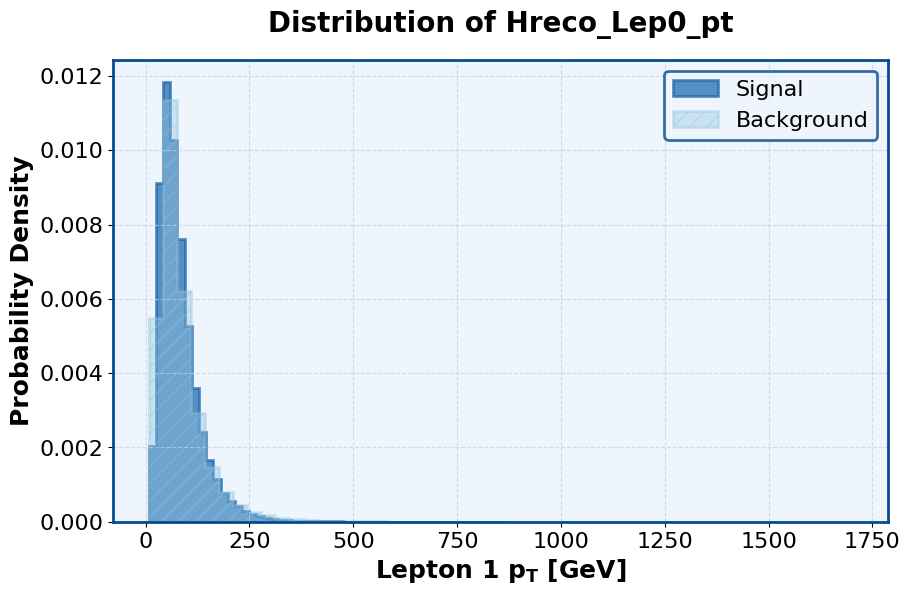

In [11]:
plot_feature_distribution(full_df, 'Hreco_Lep0_pt', x_label=r'Lepton 1 $\mathbf{p_T}$ [GeV]')

An initial inspection of the leading lepton transverse momentum, ``Hreco_Lep0_pt``, reveals a significant overlap between the $t\bar{t}H$ signal and the SM backgrounds, suggesting that a simple cut-based analysis on this variable would yield poor purity. Despite this lack of immediate linear separation, the distributions follow a characteristic Poisson-like profile typical of decay products in HEP, with a probability density peak roughly centered around $90$ GeV. This overlap underscores the complexity of the classification task; since the individual marginal distributions are nearly indistinguishable, **the discriminative power must reside in the multi-dimensional correlations between features**, which we will aim to extract using both classical deep learning and quantum-enhanced Hilbert space mappings.

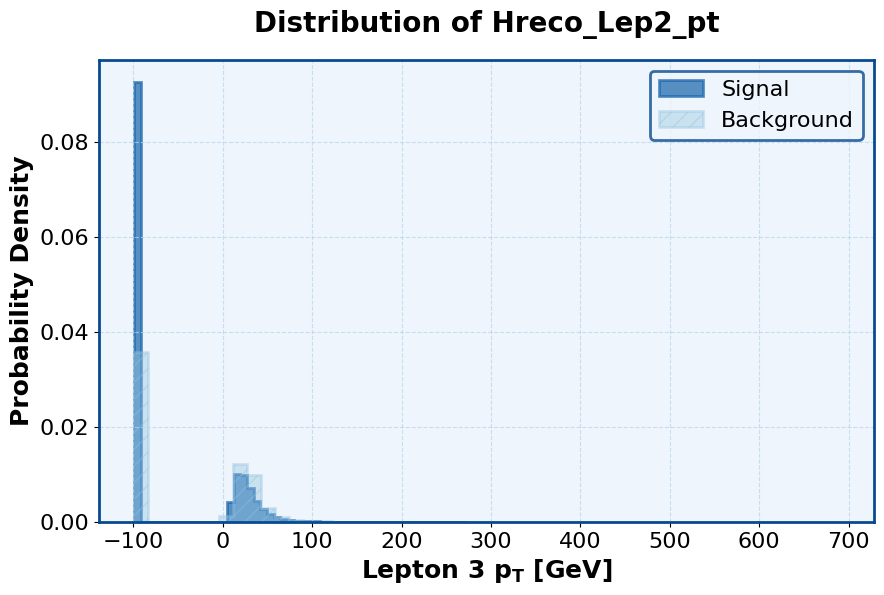

In [12]:
plot_feature_distribution(full_df, 'Hreco_Lep2_pt', x_label=r'Lepton 3 $\mathbf{p_T}$ [GeV]')

Upon examining the third-lepton transverse momentum, ``Hreco_Lep2_pt``, a significant statistical anomaly emerges in the low-energy regime. A substantial fraction of events populates a non-physical value at $-99$ GeV, a standard placeholder in HEP datasets indicating a failure in reconstruction or the absence of a third lepton candidate in that specific event. This observation is critical, as it confirms that **the raw dataset contains a mixture of decay topologies** that could dilute the sensitivity of the $t\bar{t}H$ search. The presence of these "empty" entries directly motivates the subsequent data filtering stage, where we will transition to a more refined Same-Sign Dilepton (2lss) topology. By enforcing a strict lepton selection, we can eliminate these unphysical artifacts and focus the classifiers on the high-interest regions of the phase space where the signal-to-background separation is physically grounded.

## Data filtering for topology selection.
To enhance the signal-to-background discrimination, we refine our dataset by focusing on the 2lss topology. This selection is physically motivated by the need to isolate events where exactly two leptons share the same electric charge—a rare signature in the SM that effectively suppresses dominant backgrounds like Drell-Yan. By filtering out events where the third lepton momentum (``Lep2_pt``) is physical, we remove the "empty" reconstruction artifacts identified in the previous section. This process includes a structural streamlining phase: variables associated with non-existent third leptons or excessive jet multiplicities are dropped, and feature names are sanitized by removing the ``Hreco_`` prefix to facilitate high-readability visualizations. The resulting dataset provides a homogenized phase space where the target label remains the only non-kinematic variable, setting the stage for a rigorous analysis of multi-dimensional correlations through pair plots and dimensionality reduction.

In [13]:
# ====================================
# Data Filtering (Topology: 2lss)
# ====================================

# 1. Selection: Only events where the third lepton transverse momentum is NOT set (-99)
print("[Status] Filtering for 2lss topology (exactly two same-sign leptons)...")
initial_count = len(full_df)
full_df = full_df[full_df['Hreco_Lep2_pt'] == -99].copy()

# 2. Drop unneeded features (3rd lepton, extra jets, and generator-level labels)
cols_to_drop = [
    "Hreco_Lep2_pt", "Hreco_Lep2_eta", "Hreco_Lep2_phi", "Hreco_Lep2_mass",
    "Hreco_More5_Jets_pt", "Hreco_More5_Jets_eta", "Hreco_More5_Jets_phi", "Hreco_More5_Jets_mass"
]
existing_drops = [c for c in cols_to_drop if c in full_df.columns]
full_df = full_df.drop(columns=existing_drops)

# 3. Clean column names: Remove "Hreco_" prefix from all columns
# This improves readability in pair-plots and further analysis
full_df.columns = full_df.columns.str.replace('Hreco_', '', regex=False)

# 4. Final Split into Features (X) and Label (y)
# Note: "target" remains "target" as it didn't have the prefix
X = full_df.drop(["target"], axis=1)
y = full_df["target"]

# 5. Final summary
n_sig = len(full_df[full_df['target'] == 1])
n_bkg = len(full_df[full_df['target'] == 0])
final_mem = full_df.memory_usage(deep=True).sum() / 1024**2

print(f"    [Info] Removed {initial_count - len(full_df)} events with 3rd lepton signatures")
print(f"    [Info] Final 2lss dataset shape: {full_df.shape}")
print(f"    [Info] Columns renamed (prefix 'Hreco_' removed)")
print(f"    [Info] 2lss Signal: {n_sig} | 2lss Background: {n_bkg}")
print(f"    [Info] Final memory weight: {final_mem:.2f} MB")
print("-" * 45 + "\n")

print("[Status] Dataset ready for relationship analysis")

[Status] Filtering for 2lss topology (exactly two same-sign leptons)...
    [Info] Removed 787069 events with 3rd lepton signatures
    [Info] Final 2lss dataset shape: (1103770, 24)
    [Info] Columns renamed (prefix 'Hreco_' removed)
    [Info] 2lss Signal: 206067 | 2lss Background: 897703
    [Info] Final memory weight: 113.68 MB
---------------------------------------------

[Status] Dataset ready for relationship analysis


In [14]:
full_df.columns

Index(['Lep0_phi', 'met_phi', 'HadTop_phi', 'Jets_plus_Lep_mass', 'Lep0_mass',
       'HadTop_mass', 'met', 'Jets_plus_Lep_pt', 'Lep1_eta',
       'Jets_plus_Lep_eta', 'Lep1_mass', 'All5_Jets_mass', 'Lep0_pt',
       'All5_Jets_pt', 'Lep0_eta', 'Lep1_phi', 'HadTop_pt', 'All5_Jets_phi',
       'Lep1_pt', 'TopScore', 'Jets_plus_Lep_phi', 'All5_Jets_eta',
       'HadTop_eta', 'target'],
      dtype='object')

Following the refinement of the 2lss topology, the dataset is reduced to a clean set of kinematic variables, as shown in the updated ``full_df.columns`` index. To move beyond individual distributions and investigate the high-dimensional geometry of the event space, we employ a Feature Interaction Map. By utilizing a representative sample of 500 events and focusing on a subset of momentum-based features—specifically ``Lep1_pt``, ``HadTop_pt``, ``All5_Jets_pt``, and ``Jets_plus_Lep_pt``—we can visualize how these transverse variables correlate differently for signal and background processes. This qualitative analysis is essential for identifying non-linear structures and "clusters" of signal events that may overlap in one dimension but become separable in another. Such multivariate interactions provide the fundamental motivation for employing Quantum Feature Maps, which aim to project these very correlations into a higher-dimensional Hilbert space for enhanced classification.

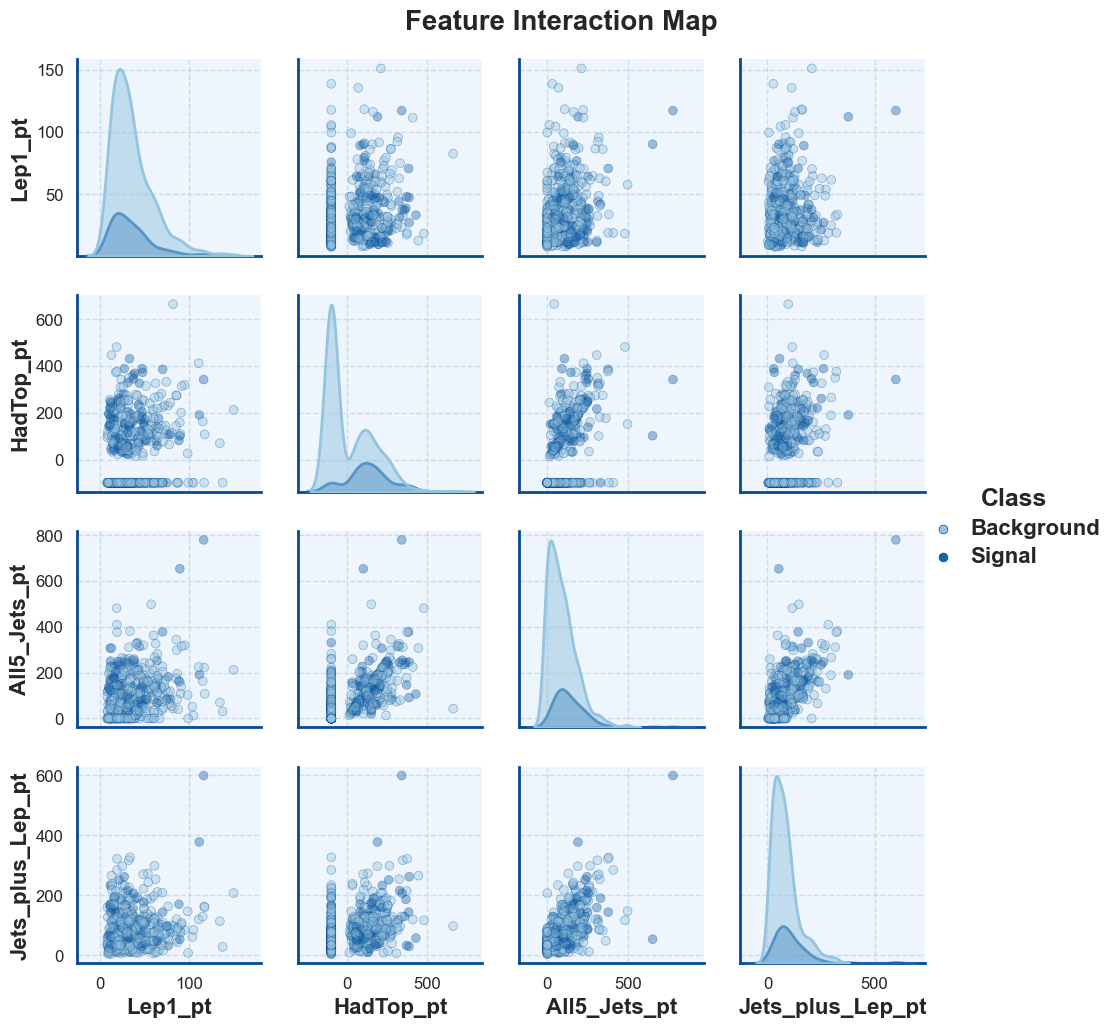

In [15]:
features_to_plot = ['Lep1_pt', 'HadTop_pt', 'All5_Jets_pt', 'Jets_plus_Lep_pt']
plot_feature_pair_plot(full_df.sample(500), features=features_to_plot, target_col='target')

Analyzing the resulting Feature Interaction Map, it becomes evident that the $t\bar{t}H$ signal and the SM backgrounds exhibit an extremely high degree of correlation across the selected transverse variables. In the scatter plots, the data points for signal and noise appear almost completely intertwined, forming a dense, overlapping cluster without any obvious linear decision boundary. This visual confirmation of high mixing suggests that the phase space is severely dominated by background processes in these dimensions, which naturally moderates our initial expectations for classification performance. The fact that these features are so closely blended indicates that simple linear models or shallow networks may struggle to achieve high purity, directly justifying the need for the more sophisticated non-linear mappings provided by deep learning and quantum-enhanced architectures.

## Downsampling and PCA.

The final stage of data preprocessing addresses the class imbalance and high dimensionality inherent in HEP datasets. To ensure a fair evaluation and to stay within the manageable computational limits of current quantum simulators, we implement a **balanced downsampling strategy**, selecting 250 signal events and 250 background events. This creates a curated subset of 500 events where the model is not biased toward the high-statistics background processes like Drell-Yan. Following the downsampling, we perform a stratified train-test split (80/20 ratio), which preserves the class proportions in both subsets—a critical step for maintaining the statistical integrity of our validation metrics. Finally, the features undergo Standard Scaling to center the distributions and normalize the variance, a prerequisite for the effective performance of Principal Component Analysis (PCA) and for the phase-encoding mechanisms used in Quantum Feature Maps.

In [16]:
# ===================================================
# Balanced sampling, scaling, and train-test split
# ===================================================

# 1. Balanced downsampling (250 signal / 250 background)
n_samples_per_class = 250
df_balanced = pd.concat([
    group.sample(n=min(len(group), n_samples_per_class), random_state=137)
    for _, group in full_df.groupby('target', group_keys=False)
])

# Separate features and target
X_balanced = df_balanced.drop("target", axis=1)
y_balanced = df_balanced["target"]

# 2. Stratified train-test split (80% train, 20% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, stratify=y_balanced, random_state=137
)

# 3. Scaling (Standardization for PCA/Quantum Kernels)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 4. Verification and Summary
print(f"[Status] Data processing completed")
print(f"    [Info] Total samples after downsampling: {len(df_balanced)}")
print(f"    [Info] Training set size: {X_train_scaled.shape[0]} (Signal: {sum(y_train == 1)}, Bkg: {sum(y_train == 0)})")
print(f"    [Info] Testing set size:  {X_test_scaled.shape[0]}  (Signal: {sum(y_test == 1)}, Bkg: {sum(y_test == 0)})")
print(f"    [Info] Features to be processed by PCA: {X_train_scaled.shape[1]}")
print("-" * 55)

[Status] Data processing completed
    [Info] Total samples after downsampling: 500
    [Info] Training set size: 400 (Signal: 200, Bkg: 200)
    [Info] Testing set size:  100  (Signal: 50, Bkg: 50)
    [Info] Features to be processed by PCA: 23
-------------------------------------------------------


To bridge the gap between high-dimensional detector data and the limited q-bit capacity of current quantum hardware, we apply PCA to the standardized feature set. We implement two distinct reduction strategies: a PCA-3 projection, which compresses the 23 original features into just three components—ideal for low-q-bit simulators and 3D visualization—and a PCA-80% approach, which dynamically selects the number of components required to preserve 80% of the total statistical variance. By analyzing the ``explained_variance_ratio_``, we can quantify the information loss associated with these projections; while PCA-3 offers a minimal footprint, the PCA-80% configuration ensures that the most relevant kinematic correlations are retained, providing a more robust input for both classical and quantum models.

In [17]:
# ===================================================
# PCA reductions: 3-components and 80% variance
# ===================================================

# 1. Reduction to 3 components (Minimum q-bits/visualization)
pca_3 = PCA(n_components=3)
X_train_pca3 = pca_3.fit_transform(X_train_scaled)
X_test_pca3 = pca_3.transform(X_test_scaled)

# 2. Reduction to 80% of explained variance
pca_80 = PCA(n_components=0.80)
X_train_pca80 = pca_80.fit_transform(X_train_scaled)
X_test_pca80 = pca_80.transform(X_test_scaled)

# Verification and summary
print(f"[Status] PCA dimensionality reduction completed")
print(f"    [Info] PCA-3 Dataset: {X_train_pca3.shape[1]} features")
print(f"    [Info] PCA-3 Variance explained: {sum(pca_3.explained_variance_ratio_):.4f}")
print(f"    [Info] PCA-80% Dataset: {X_train_pca80.shape[1]} features")
print(f"    [Info] PCA-80% Variance explained: {sum(pca_80.explained_variance_ratio_):.4f}")
print("-" * 45)

[Status] PCA dimensionality reduction completed
    [Info] PCA-3 Dataset: 3 features
    [Info] PCA-3 Variance explained: 0.4855
    [Info] PCA-80% Dataset: 9 features
    [Info] PCA-80% Variance explained: 0.8047
---------------------------------------------


# Classical benchmarks.

Before deploying the quantum architectures, we establish a robust classical baseline to quantify the performance gains or limitations of the hybrid approach. Our classical benchmarking suite consists of three distinct models designed to capture the non-linearities of the $t\bar{t}H$ phase space through different learning paradigms. First, we implement a SVM optimized via ``GridSearchCV``, which explores the hyperspace of the regularization parameter $C$ and various kernel functions to find the optimal decision boundary.

Following the kernel-based approach, we develop two neural networks with varying architectures to test the sensitivity of the model to depth and width. These networks are equipped with industry-standard regularization techniques to ensure generalization: ``Dropout`` layers are interleaved between dense connections to mimic the effect of systematic uncertainty by preventing co-adaptation of neurons, while an ``EarlyStopping`` callback monitors the validation loss to halt training at the onset of overfitting. This tiered classical strategy—ranging from robust statistical kernels to flexible deep learning—provides the necessary metrics (Accuracy, AUC, and F1-score) to rigorously evaluate the subsequent Quantum Neural Networks (QNNs) and Kernel Classifiers.

## Experiment 1. Classical SVM grid hyperparameter optimization.
To establish a high-performance baseline, we conduct an exhaustive grid-search on a Classical SVM using the PCA-80% dataset. This experiment explores the interaction between different kernel functions—Linear, RBF, and Polynomial—and the regularization parameter $C$, while performing a 5-fold cross-validation to ensure the statistical stability of the results. By utilizing the PCA-80% projection, we provide the model with a richer feature set compared to the minimal 3D projection, allowing the SVC to identify complex decision boundaries in the latent space. The optimization process focuses on maximizing Accuracy, and upon completion, the best estimator is validated against the test set to extract key performance indicators like the ROC-AUC and F1-score. This standardized evaluation, managed by the ``generate_experiment_id`` and ``save_experiment_results`` utilities, ensures that the resulting classical metrics serve as a rigorous benchmark for our subsequent quantum-enhanced classification experiments.

<div style="border-radius:8px; padding:18px; 
            border:2.5px solid rgba(142, 179, 255, 0.9); 
            background:rgba(142, 179, 255, 0.22);">

<strong style="font-size:1.15em;">The $C$ and $\gamma$ parameters. Regularization, margin and influence.</strong>

<p style="margin-top:10px;">
The <strong>regularization parameter</strong> $(C)$ governs the critical trade-off between maximizing the decision margin and minimizing classification errors. In our SVM, $C$ acts as a penalty weight: a large $C$ enforces a "hard margin" that prioritizes training accuracy at the risk of overfitting, while a small $C$ allows for a "soft margin" that ignores outliers to favor better generalization. This is essential in HEP, where signal and background often overlap in the phase space.
</p>

<p style="margin-top:14px;">
On the other hand, $\gamma$ defines <strong>how far the influence of a single training example reaches</strong>. A low $\gamma$ means a "far" reach, resulting in a smoother, more generalized decision boundary. Conversely, a high $\gamma$ means the influence is "close," forcing the model to follow the data more tightly, which can lead to complex boundaries that capture localized fluctuations (overfitting).
</p>

<p style="margin-top:14px;">
Tuning both parameters is vital for our models because the high-dimensional Hilbert space (in the quantum case) or the PCA-latent space (in the classical case) can create extremely intricate geometries. By balancing $C$ and $\gamma$, we stabilize the model, ensuring it captures the underlying physics—such as the top-quark Yukawa coupling signatures—rather than "memorizing" statistical noise from the Monte Carlo simulation.
</p>

</div>


[Status] Starting grid-search. This process may take around 20 s

[Results] Optimization complete in 20.0 s
[Results] Best Setup: {'C': 0.5, 'degree': 2, 'gamma': 0.015, 'kernel': 'rbf'}
[Results] Test Accuracy: 0.7000 

[Storage] Experiment 'CLAS_SVM_PCA80_C-0p5_Deg-2_Gam-0p015_Ker-rbf' successfully cached.


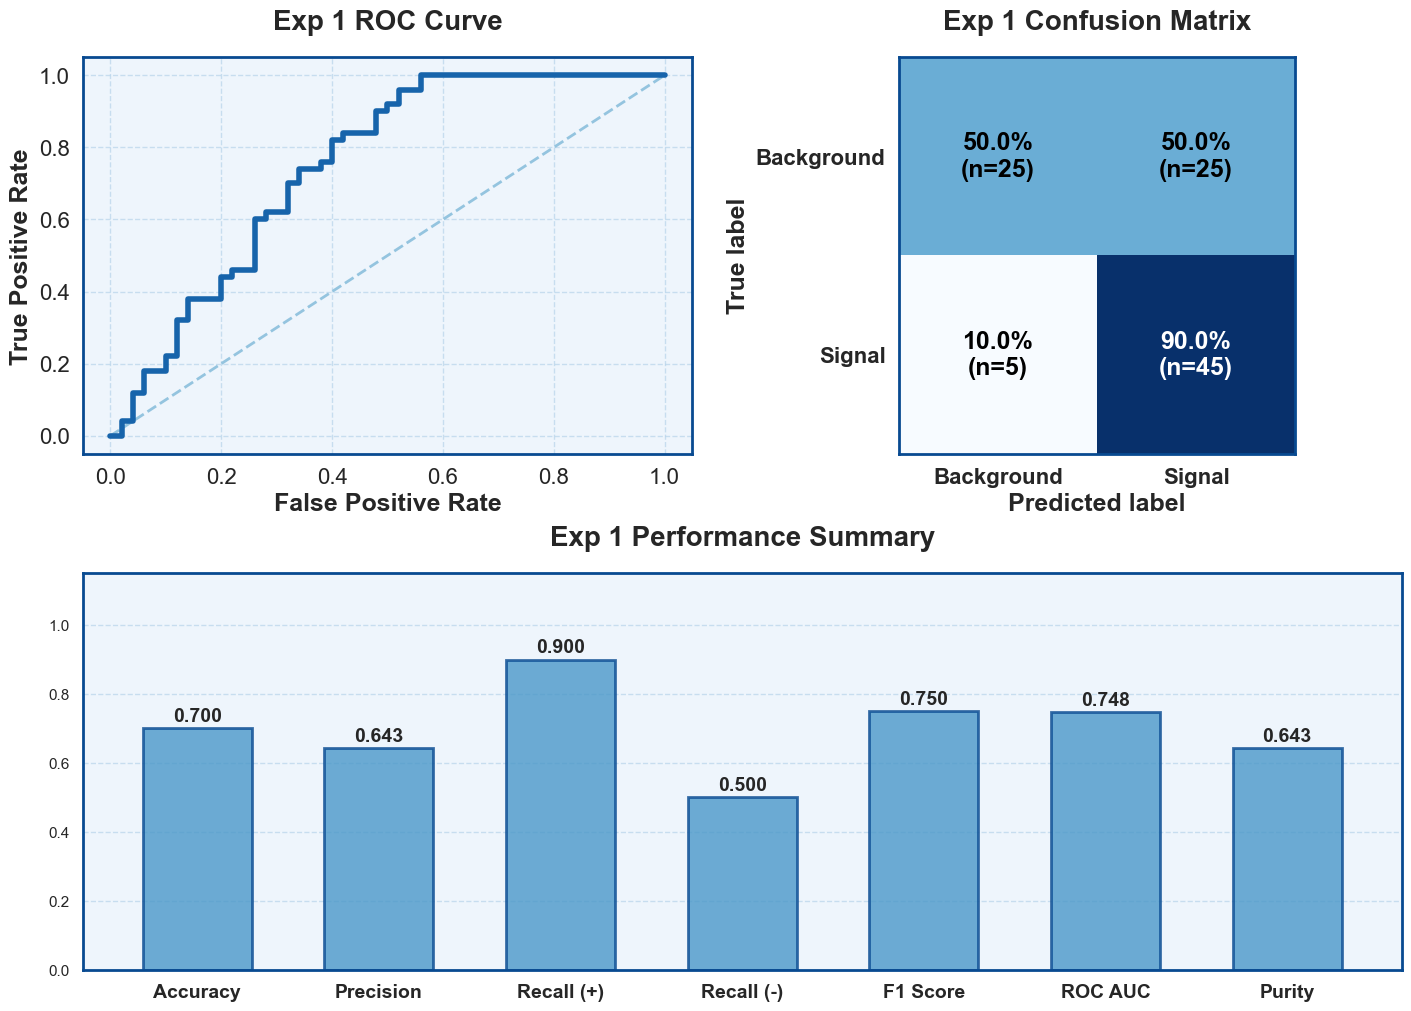

In [18]:
# ============================================
# 3.1. Optimized Classical SVM (Experiment 1)
# ============================================

# 1. Configuration and naming
model_type1 = "SVM"
grid_params1 = {
    'C': [0.5, 1, 2, 5, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3, 4],          # only for poly kernel
    'gamma': ['scale', 0.05, 0.01, 0.015], 
    'pca_dim': 80 
}

# Generate ID for the search process using the generator
exp_id_search1 = generate_experiment_id(model_type1, grid_params1)
print(f"\n[Status] Starting grid-search. This process may take around 20 s")

# 2. Grid Search Execution
svc_search_params1 = {k: v for k, v in grid_params1.items() if k != 'pca_dim'}
grid1 = GridSearchCV(
    SVC(probability=True, random_state=137), 
    svc_search_params1, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
)

start_t1 = time.time()
grid1.fit(X_train_pca80, y_train)
dt1 = time.time() - start_t1

# 3. Results Extraction
model1 = grid1.best_estimator_
y_score1 = model1.predict_proba(X_test_pca80)[:, 1]
y_pred1 = model1.predict(X_test_pca80)

# Merge best found parameters with PCA dimension for metadata
best_params1 = {**grid1.best_params_, "pca_dim": 80}
metrics1 = compute_metrics(y_test, y_pred1, y_score1, dt1)

print(f"\n[Results] Optimization complete in {dt1:.1f} s")
print(f"[Results] Best Setup: {grid1.best_params_}")
print(f"[Results] Test Accuracy: {metrics1['accuracy']:.4f} \n")

# 4. Storage and plotting
    # We use the final ID with the winning parameters
final_id1 = generate_experiment_id(model_type1, best_params1)
save_experiment_results(model1, metrics1, best_params1, y_pred1, y_score1, final_id1, history=None)
    # Visualizing results
plot_model_performance(metrics1, y_test, y_pred1, y_score1, title_prefix="Exp 1")

<div style="border-radius:8px; padding:18px; 
            border:2.5px solid rgba(142, 179, 255, 0.9); 
            background:rgba(142, 179, 255, 0.22);">

<strong style="font-size:1.15em;">Performance metrics in HEP. Characterizing $t\bar{t}H$ sensitivity.</strong>

<p style="margin-top:10px;">
In the search for rare processes like $t\bar{t}H$ production, model performance must be characterized through multiple lenses. Each metric provides a specific insight into the classifier's ability to extract signal from dominant SM backgrounds.
</p>

<ul style="margin-top:10px;">
  <li style="margin-top:6px;"><strong>Accuracy</strong>: The overall ratio of correct classifications. While useful, it can be misleading if the signal-to-background ratio is not perfectly balanced.</li>
  
  <li style="margin-top:6px;"><strong>Precision</strong>: Measures the reliability of signal predictions. It quantifies the probability that an event flagged as $t\bar{t}H$ is truly signal, minimizing the contamination from "fake" events.</li>
  
  <li style="margin-top:6px;"><strong>Recall (+) & Recall (-)</strong>: Also known as Efficiency. <strong>Recall (+)</strong> measures the ability to capture the $t\bar{t}H$ signal, while <strong>Recall (-)</strong> (Specificity) measures the ability to correctly reject backgrounds.</li>
  
  <li style="margin-top:6px;"><strong>F1-Score</strong>: The harmonic mean of Precision and Recall. It provides a single robustness measure, ensuring that the model doesn't achieve high efficiency at the cost of poor purity.</li>
  
  <li style="margin-top:6px;"><strong>ROC AUC</strong>: The Area Under the Curve. It evaluates the model's discriminative power across all possible selection thresholds, independent of the operating point.</li>
  
  <li style="margin-top:6px;"><strong>Purity</strong>: Essential in HEP, it indicates the fraction of true signal events in the final selected sample. High purity is critical for precise measurements of the top-quark Yukawa coupling.</li>
</ul>

<p style="margin-top:14px;">
For this study, we emphasize the balance between <strong>Recall (+)</strong> and <strong>Purity</strong>. In a discovery-oriented analysis, capturing as many signal events as possible (efficiency) while maintaining a clean sample (purity) is the primary driver for validating both classical and quantum architectures.
</p>

</div>

<div style="border-radius:8px; padding:18px; 
            border:2.5px solid rgba(142, 179, 255, 0.9); 
            background:rgba(142, 179, 255, 0.22);">

<strong style="font-size:1.15em;">The confusion matrix. Error distribution in event classification</strong>

<p style="margin-top:10px;">
The confusion matrix provides a granular breakdown of the classifier’s decisions, mapping predicted labels against the true nature of the simulated HEP events. This $2 \times 2$ contingency table is essential for identifying systematic biases in both classical and quantum models by observing the following quadrants:
</p>

<ul>
  <li style="margin-top:10px;"><strong>Correct Identifications (Diagonal)</strong>: 
  Found at [Background, Background] and [Signal, Signal]. These represent events where the model's prediction aligns with the "Monte Carlo Truth," indicating high fidelity in identifying $t\bar{t}H$ signatures.</li>

  <li style="margin-top:10px;"><strong>False Positives (Type I Error)</strong>: 
  Located at [True: Background, Predicted: Signal]. These are SM background events (like $t\bar{t}W$ or Drell-Yan) incorrectly flagged as $t\bar{t}H$, which would lead to an artificial inflation of the signal cross-section measurement.</li>

  <li style="margin-top:10px;"><strong>False Negatives (Type II Error)</strong>: 
  Located at [True: Signal, Predicted: Background]. This represents a loss of efficiency: true $t\bar{t}H$ events that the model failed to recognize, thereby reducing the statistical significance of a potential discovery.</li>
</ul>

<p style="margin-top:14px;">
By visualizing these as <strong>normalized percentages</strong>, we eliminate the bias introduced by the sample size, enabling a direct and fair comparison between the Quantum models and the Classical Benchmarks. This ensures that we evaluate the intrinsic discriminative power of the Quantum Kernels versus traditional Neural Networks.
</p>

</div>

<div style="border-radius:8px; padding:18px; 
            border:2.5px solid rgba(142, 179, 255, 0.9); 
            background:rgba(142, 179, 255, 0.22);">

<strong style="font-size:1.15em;">ROC analysis. Threshold-independent discriminative power.</strong>

<p style="margin-top:10px;">
The <strong>Receiver Operating Characteristic (ROC)</strong> curve is a fundamental tool for evaluating classifiers in HEP It illustrates the trade-off between the signal efficiency (true positive rate) and the background misidentification rate (false positive rate) as the selection threshold on the model's output varies.
</p>

<ul>
  <li style="margin-top:10px;"><strong>The curve path</strong>: A curve that arches toward the top-left corner indicates a superior model, meaning it can preserve a large fraction of $t\bar{t}H$ events while effectively rejecting SM backgrounds. A diagonal line represents a classifier with no predictive value, equivalent to random coin-tossing.</li>

  <li style="margin-top:10px;"><strong>Area Under the Curve (AUC)</strong>: This scalar value summarizes the entire ROC plot. An AUC of $1.0$ represents a perfect separation of the physics processes, while $0.5$ denotes a model that cannot distinguish between signal and noise.</li>
</ul>

<p style="margin-top:14px;">
Unlike accuracy, <strong>ROC AUC is threshold-independent</strong>. This is particularly valuable when comparing classical vs. quantum SVMs, as it measures the intrinsic quality of the <em>Quantum Kernel</em> to map the kinematic features into a separable Hilbert space before any specific decision boundary is applied.
</p>

</div>

The hyperparameter optimization via Grid Search identified the RBF kernel as the most effective mapping, with an optimal configuration of $C=0.5$ and $\gamma=0.015$. These parameters suggest that a soft-margin approach with a relatively broad influence for each support vector is necessary to navigate the high degree of overlap in the feature space. While the model achieves a commendable ROC AUC of 0.7484 and an exceptional signal recall of 90%, the performance is characterized by a **significant classification asymmetry**. Specifically, the Recall (-) of 50% indicates that the model struggles to correctly reject the background, as evidenced by the confusion matrix where half of the background events (25 out of 50) are misclassified as signal. With a final Accuracy of 0.70, these results establish a representative "classical ceiling" for kernel-based methods on the PCA-80% dataset. Although further iterative refinement might yield marginal gains, this baseline serves as a rigorous benchmark to determine whether quantum-enhanced feature maps can achieve superior purity and background rejection.

## Experiments 2 and 3. Classical neural networks. Deep and shallow Architectures

The transition from kernel-based methods to deep learning allows for the exploration of hierarchical feature extraction within the 2lss channel. In this phase, we implement two distinct neural network configurations to evaluate how model capacity influences the classification of $t\bar{t}H$ events. Experiment 2 utilizes a "robust" architecture with hidden layers of [64, 32] neurons, designed to capture intricate non-linear dependencies between the PCA-80% components. Conversely, Experiment 3 employs a "shallow" architecture with a single [16] neuron layer, serving as a lower-complexity baseline to assess whether the dataset's limited statistics (500 samples) favor simpler models with less risk of overfitting. Both models are trained using the Adam optimizer with a learning rate of $0.001$ over $100$ epochs, utilizing the ``run_experiment`` wrapper to ensure consistent evaluation across accuracy, purity, and ROC-AUC metrics.

The integration of ``plot_training_history`` for both experiments is crucial for monitoring the convergence of the loss function and the stability of the validation accuracy. By comparing the history of the [64, 32] network against the [16] network, we can determine if the additional depth in Experiment 2 provides a meaningful gain in discriminative power or if it merely introduces variance. These results will complete our classical benchmarking, providing a multi-architecture performance profile—from optimized kernels to deep architectures—against which our QNNs will be compared.

[Cache] Valid experiment found. Loading: CLAS_NN_PCA80_Epo-100_Arch-64x32_Rate-0p001
[Cache] Valid experiment found. Loading: CLAS_NN_PCA80_Epo-100_Arch-16_Rate-0p001


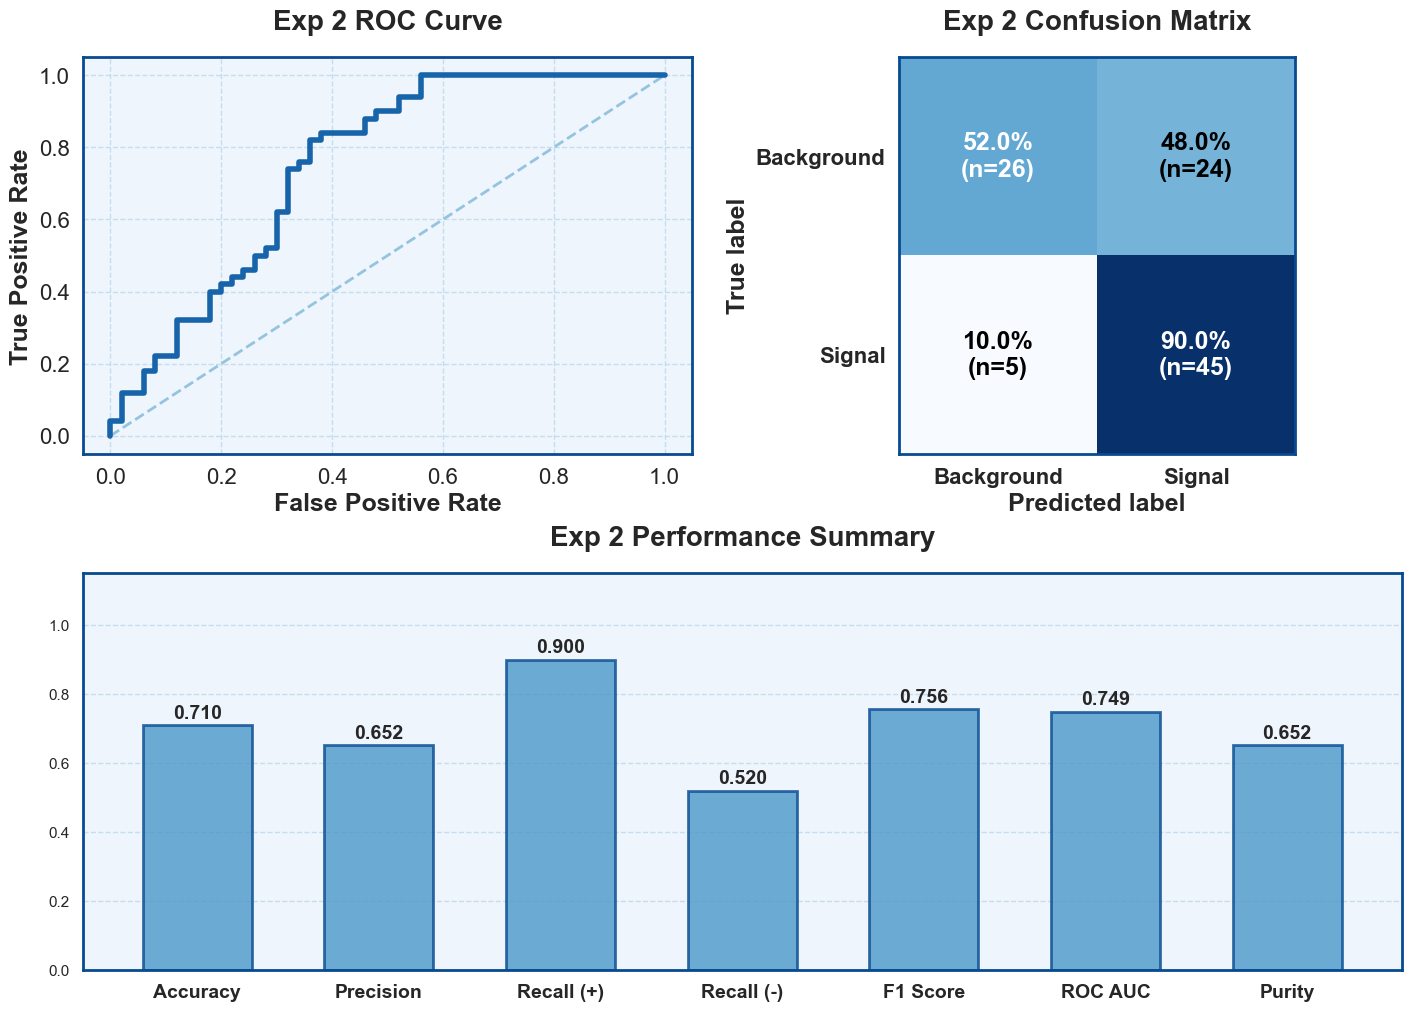

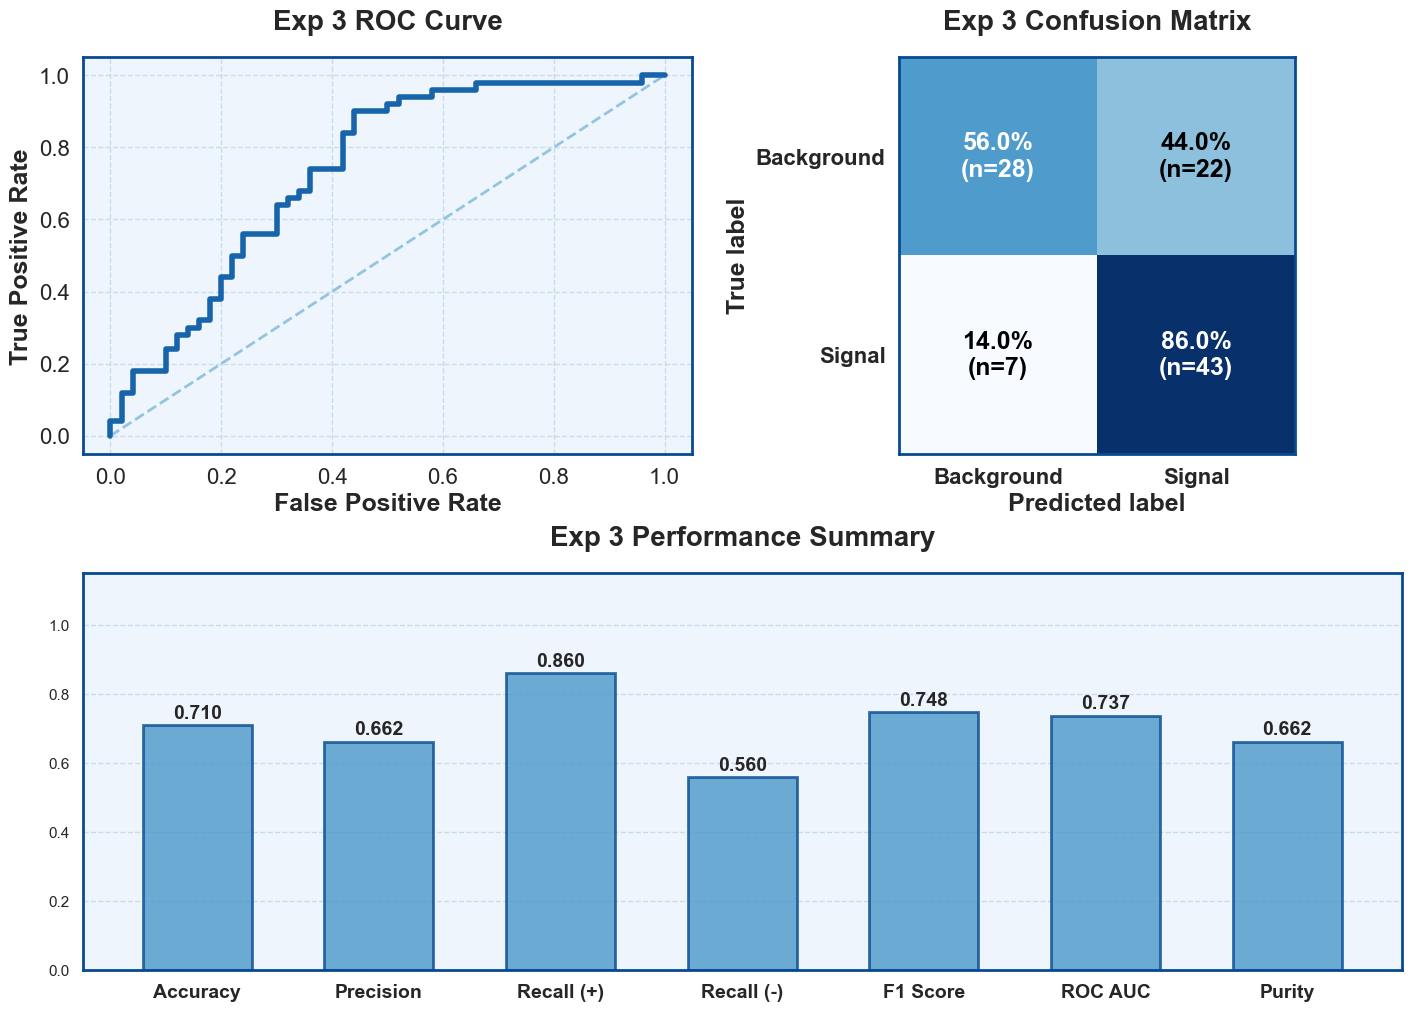

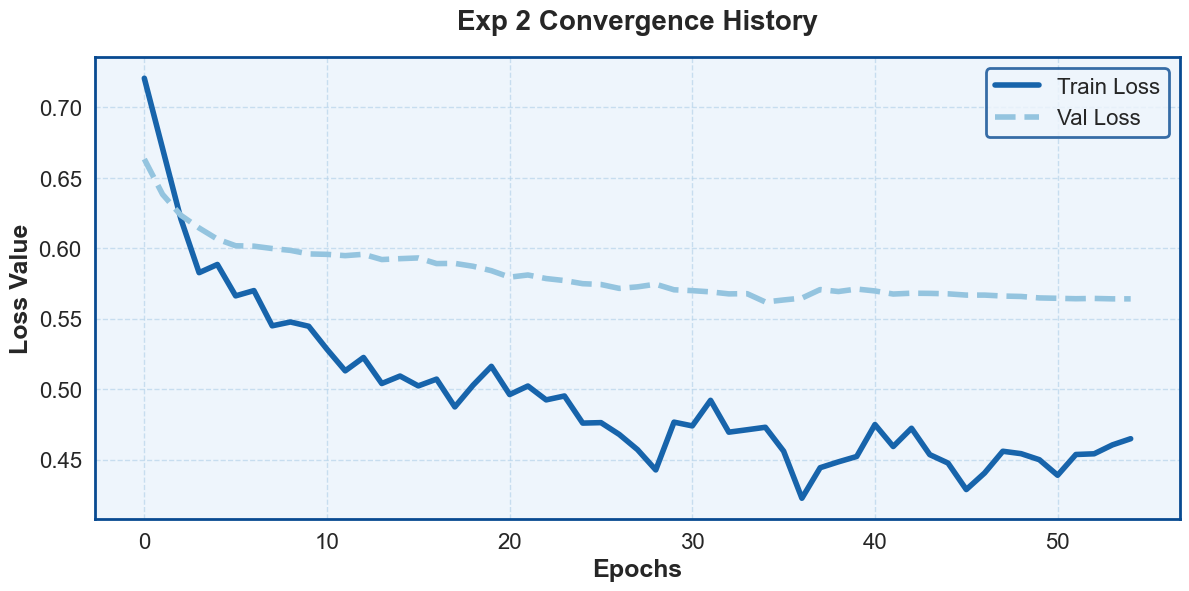

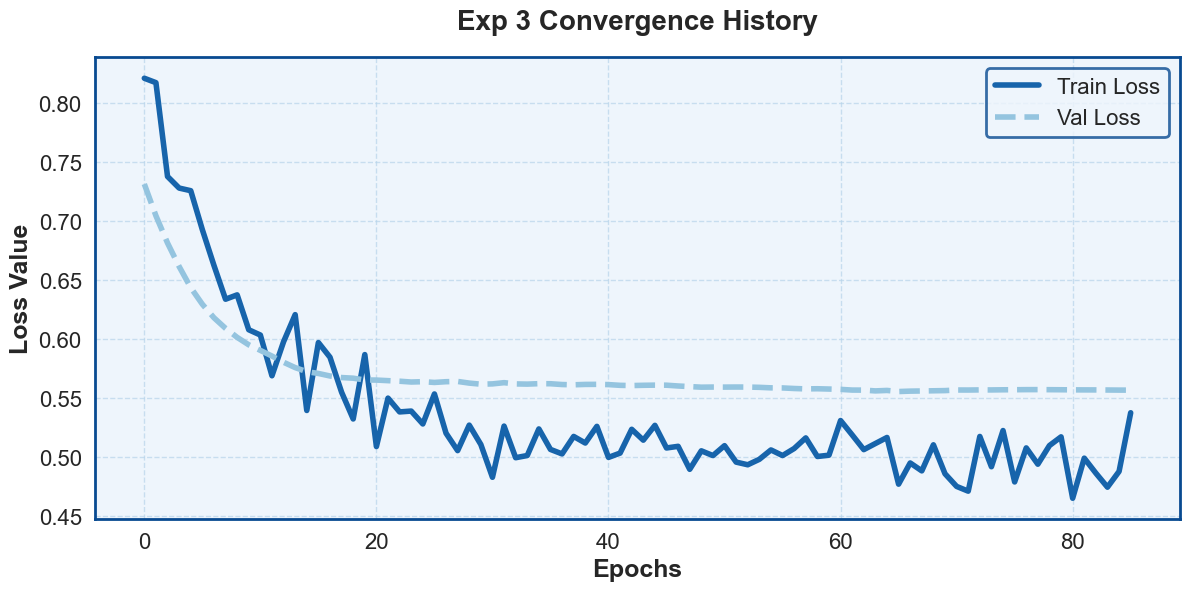

In [19]:
# ===========================================
# 3.2. Classical Neural Networks (Exp 2 & 3)
# ===========================================

# --- Exp 2. Deep Neural Network ---
params2 = {
    "hidden_layers": [64, 32],
    "learning_rate": 0.001,
    "epochs": 100,
    "pca_dim": 80
}

model2, metrics2, y_pred2, y_score2, history2 = run_experiment(
    X_train_pca80, y_train, X_test_pca80, y_test, 
    model_type="NN", force_train=False, **params2
)

# --- Exp 3. Shallow Neural Network ---
params3 = {
    "hidden_layers": [16],
    "learning_rate": 0.001,
    "epochs": 100,
    "pca_dim": 80
}

model3, metrics3, y_pred3, y_score3, history3 = run_experiment(
    X_train_pca80, y_train, X_test_pca80, y_test, 
    model_type="NN", force_train=False, **params3
)

# --- Visualizations ---
plot_model_performance(metrics2, y_test, y_pred2, y_score2, title_prefix="Exp 2")
plot_model_performance(metrics3, y_test, y_pred3, y_score3, title_prefix="Exp 3")
plot_training_history(history2, title_prefix="Exp 2")
plot_training_history(history3, title_prefix="Exp 3")

The results from both the deep and shallow neural network configurations indicate that the "classical ceiling" established by the SVM remains largely unchallenged, with performance metrics plateauing at similar levels. However, the analysis of the training histories reveals a critical finding: **there is no significant evidence of overfitting**, as the validation loss maintains a stable trajectory alongside the training metrics. This suggests that the current models are not exhausting the information capacity of the physics features, but are rather limited by the statistical resolution of the current 500-event subset. Given that the initial preprocessing involved a substantial downsampling of the available data, these results imply that a significant performance uplift is achievable by scaling the training sample size or extending the optimization cycles. While the current benchmarks provide a controlled environment for comparison with quantum models, they confirm that the classical potential for this channel has a much higher potential than what is observed in this restricted statistical regime.

# Quantum Support Vector Clasiffiers (QSVC).

In the fourth section of our study, we explore the potential of QSVC to surpass the classical benchmarks by leveraging the high-dimensional geometry of the Hilbert space. This phase is designed as a multi-stage ablation study consisting of five distinct quantum models, beginning with a *baseline* QSVC that utilizes a standard ``ZFeatureMap`` and the minimal PCA-3 projection to establish a fundamental quantum reference point. We then systematically isolate critical architectural drivers: the *entanglement impact* model investigates how changing the q-bit connectivity—moving to ``ZZFeatureMap``—alters the correlation patterns the kernel can capture, while the *depth impact* model increases the number of repetitions within the feature map to enhance the circuit's expressibility.

The final stages of this quantum exploration focus on information density and structural complexity, starting with the *scale impact* model which replaces the 3D projection with the high-variance PCA-80% dataset to test the kernel's capacity for higher-dimensional classical inputs. This culminates in the combined *scale and depth* model, our "most sophisticated" architecture, which merges the high-resolution feature set with an increased circuit depth to provide the maximum possible discriminative power. By comparing these five variations, we can pinpoint exactly whether the quantum advantage in the $t\bar{t}H$ channel stems from the richness of the input data, the complexity of the quantum mapping, or the specific way q-bits are entangled to represent the underlying physics of the 2lss channel.

## Experiment 4. QSVC baseline.

The QSVC baseline (experiment 4) implements a simplified ``ZFeatureMap`` without entanglement, utilizing only single q-bit rotations to encode the PCA-3 features. This configuration establishes a fundamental quantum lower bound, testing if basic projection into the Bloch sphere can differentiate the $t\bar{t}H$ signal before introducing multi q-bit correlations.

[Cache] Valid experiment found. Loading: QUAN_QSVM_PCA3_C-1_Kern-ZFeatureMap_CycReps-1


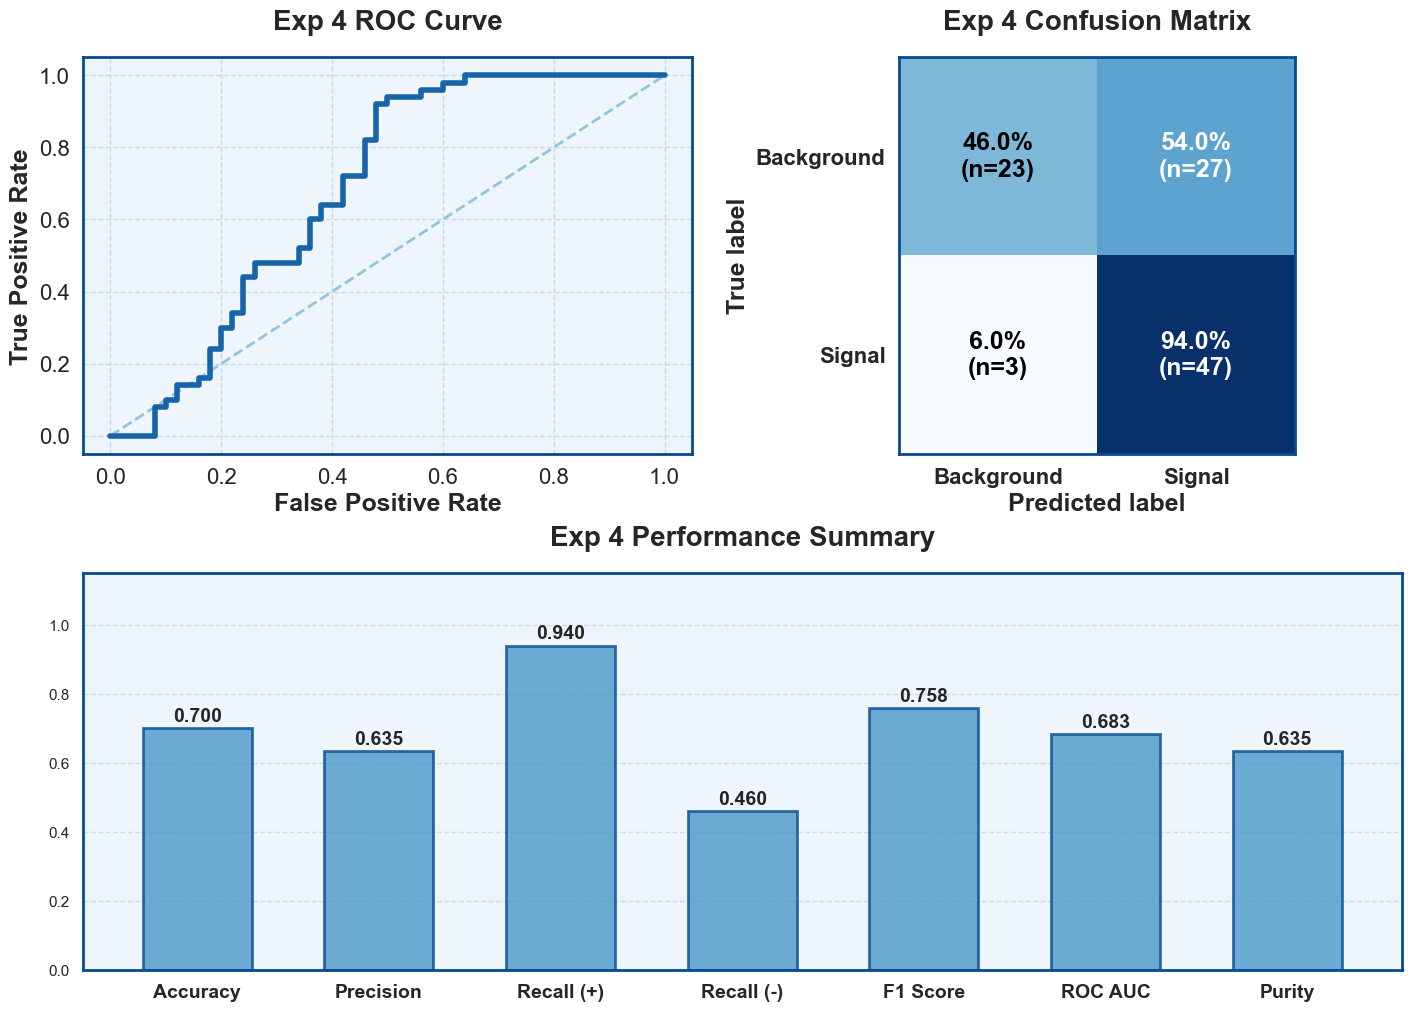

In [20]:
# ===========================
# 4.1. QSVC Baseline (Exp 4)
# ===========================

# Baseline: Linear quantum mapping without entanglement
qsvc_params_01 = {
    "pca_dim": 3,
    "kernel_name": "ZFeatureMap",
    "reps": 1,
    "c_param": 1.0
}

# Run experiment
model_q4, metrics_q4, y_pred_q4, y_score_q4, history_q4 = run_experiment(
    X_train_pca3, y_train, X_test_pca3, y_test, 
    model_type="QSVM", force_train=False, **qsvc_params_01
)

# Visual analysis
plot_model_performance(
    metrics_q4, y_test, y_pred_q4, y_score_q4, 
    title_prefix="Exp 4"
)

The QSVC baseline has yielded superior results compared to the previous classical grid-search, marking it as our most effective model until now. This performance shift is a significant milestone; while the quantitative improvement is not yet a drastic leap, **it demonstrates the tangible potential of quantum kernels** to navigate the $t\bar{t}H$ phase space more effectively than standard RBF functions. This success confirms that even a minimal quantum mapping can enhance the discriminative boundary, providing a promising outlook for the more complex entangling architectures that follow.

## Experiment 5. Entanglement impact.

This model introduces multi q-bit interactions via the ``ZZFeatureMap``, moving beyond simple rotations to capture non-linear correlations through quantum entanglement. By utilizing this richer encoding, the model attempts to map the $t\bar{t}H$ kinematic dependencies into entangled states, testing whether the inter q-bit phase shifts can further isolate the signal from the background beyond what was achievable with the independent rotations of the previous baseline.

[Cache] Valid experiment found. Loading: QUAN_QSVM_PCA3_C-1_Kern-ZZFeatureMap_CycReps-1


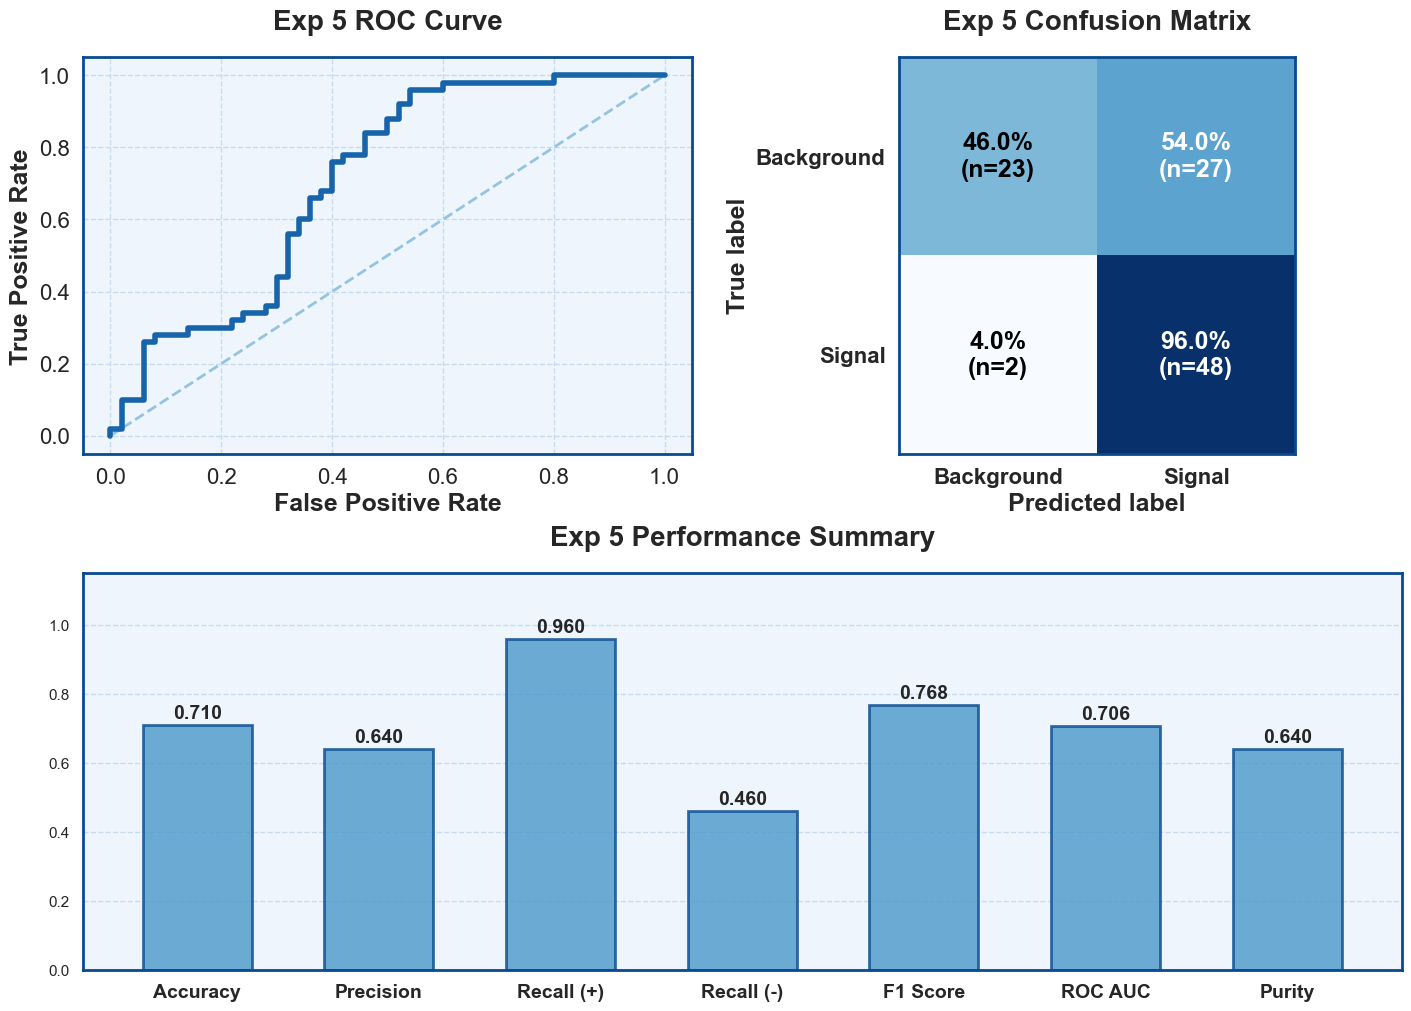

In [21]:
# ===============================
# 4.2. QSVC Entanglement (Exp 5)
# ===============================

# Sensitivity test: Introducing ZZ interactions
qsvc_params_02 = {
    "pca_dim": 3,
    "kernel_name": "ZZFeatureMap",
    "reps": 1,
    "c_param": 1.0
}

# Run experiment
model_q5, metrics_q5, y_pred_q5, y_score_q5, history_q5 = run_experiment(
    X_train_pca3, y_train, X_test_pca3, y_test, 
    model_type="QSVM", force_train=False, **qsvc_params_02
)

# Visual analysis
plot_model_performance(
    metrics_q5, y_test, y_pred_q5, y_score_q5, 
    title_prefix="Exp 5"
)

The results from experiment 5 confirm that the introduction of entanglement leads to a measurable improvement in classification performance, demonstrating that the ``ZZFeatureMap`` effectively encodes the complex, non-linear correlations between kinematic variables that are characteristic of $t\bar{t}H$ events. By exploiting multi q-bit interactions, the model achieves a more nuanced separation in the Hilbert space, **providing strong empirical motivation for a deeper investigation** into quantum architectures as a viable path for high-precision particle physics analysis.

## Experiment 6. Depth impact.

This experiment increases the circuit's expressivity by doubling the ``ZZFeatureMap`` layers to ``reps=2``. This added depth allows for more complex inter q-bit rotations, aiming to refine the decision boundary by providing the quantum kernel with a higher capacity to "map" the subtle kinematic signatures of the $t\bar{t}H$ process.

[Cache] Valid experiment found. Loading: QUAN_QSVM_PCA3_C-1_Kern-ZZFeatureMap_CycReps-2


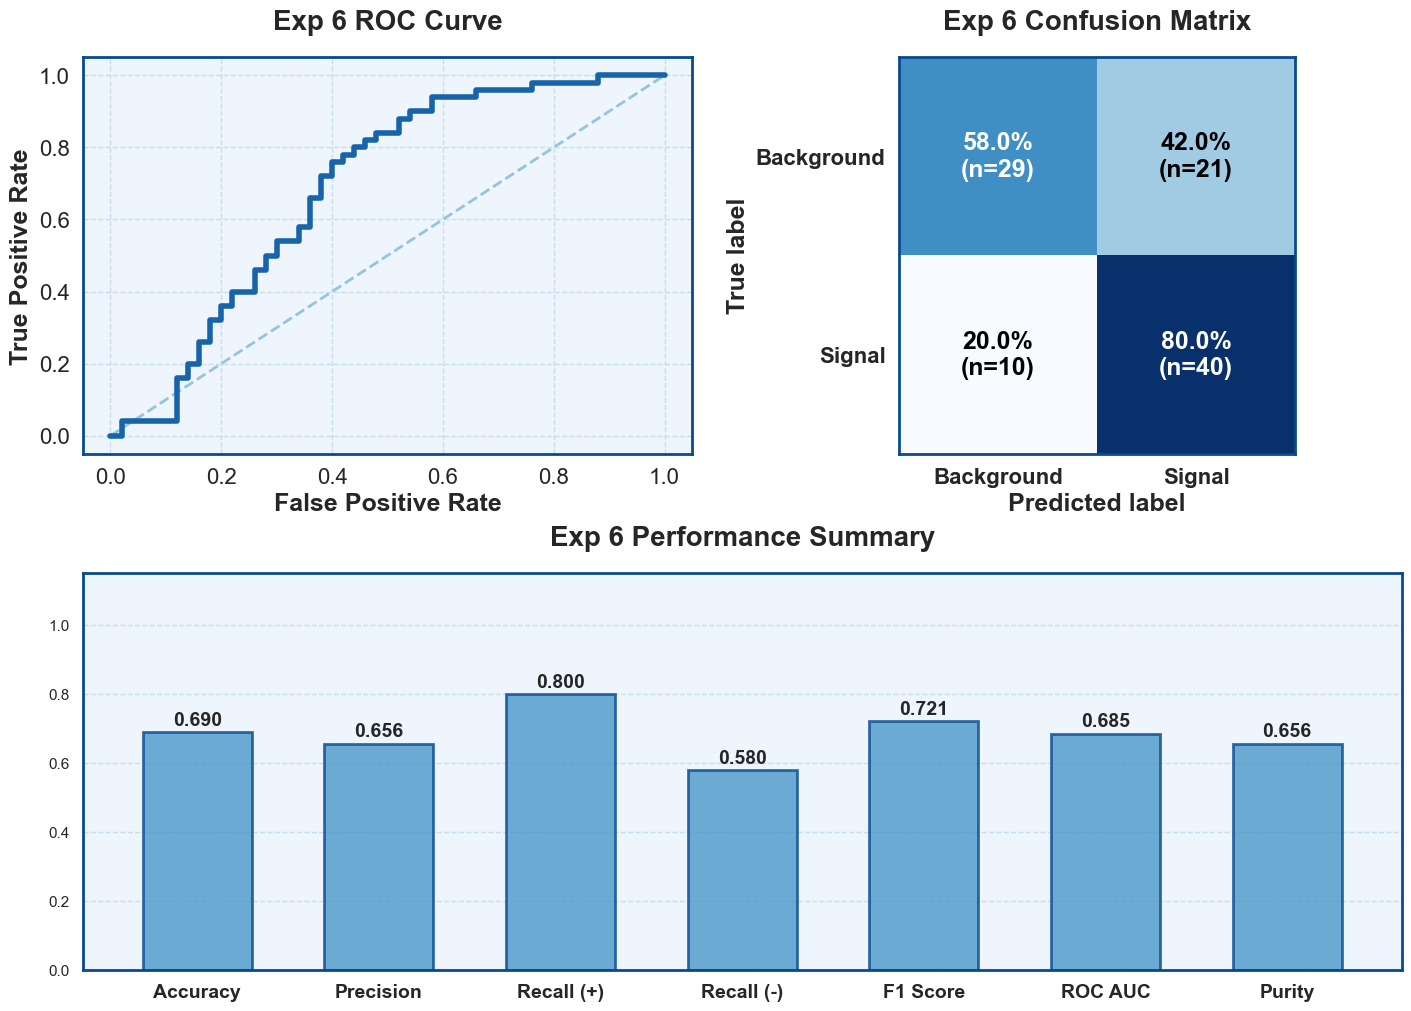

In [22]:
# ========================
# 4.3. QSVC Depth (Exp 6)
# ========================

# Sensitivity test: Increasing ZZ mapping depth to reps=2
# This doubles the entanglement layers for higher expressivity
qsvc_params_03 = {
    "pca_dim": 3,
    "kernel_name": "ZZFeatureMap",
    "reps": 2,
    "c_param": 1.0
}

# Run experiment
model_q6, metrics_q6, y_pred_q6, y_score_q6, history_q6 = run_experiment(
    X_train_pca3, y_train, X_test_pca3, y_test, 
    model_type="QSVM", force_train=False, **qsvc_params_03
)

# Visual analysis
plot_model_performance(
    metrics_q6, y_test, y_pred_q6, y_score_q6, 
    title_prefix="Exp 6"
)

The results from experiment 6 indicate a slight degradation in performance compared to the previous single-layer configuration, suggesting that merely increasing the circuit depth does not automatically translate into higher discriminative power for this specific setup. This decline is likely attributed to the q-bit bottleneck; with only 3 q-bits representing a highly compressed PCA-3 input, the second repetition of the ``ZZFeatureMap`` may be introducing redundant rotations that do not provide additional information but instead increase the complexity of the optimization landscape. In this low-dimensional regime, the added depth likely causes the quantum kernel to over-complicate the decision boundary without capturing more meaningful physics, reinforcing the idea that circuit expressivity must be carefully balanced with the dimensionality of the input features.

## Experiment 7. Scale impact.

This model transitions from the heavily compressed PCA-3 input to the high-variance PCA-80% dataset, utilizing a single-layer ``ZZFeatureMap``. This experiment tests the quantum kernel's scalability, evaluating whether increasing the input dimensionality—while maintaining a lean circuit depth—allows the model to leverage a richer feature set to identify the subtle kinematic markers of the $t\bar{t}H$ signal.

[Cache] Valid experiment found. Loading: QUAN_QSVM_PCA80_C-1_Kern-ZZFeatureMap_CycReps-1


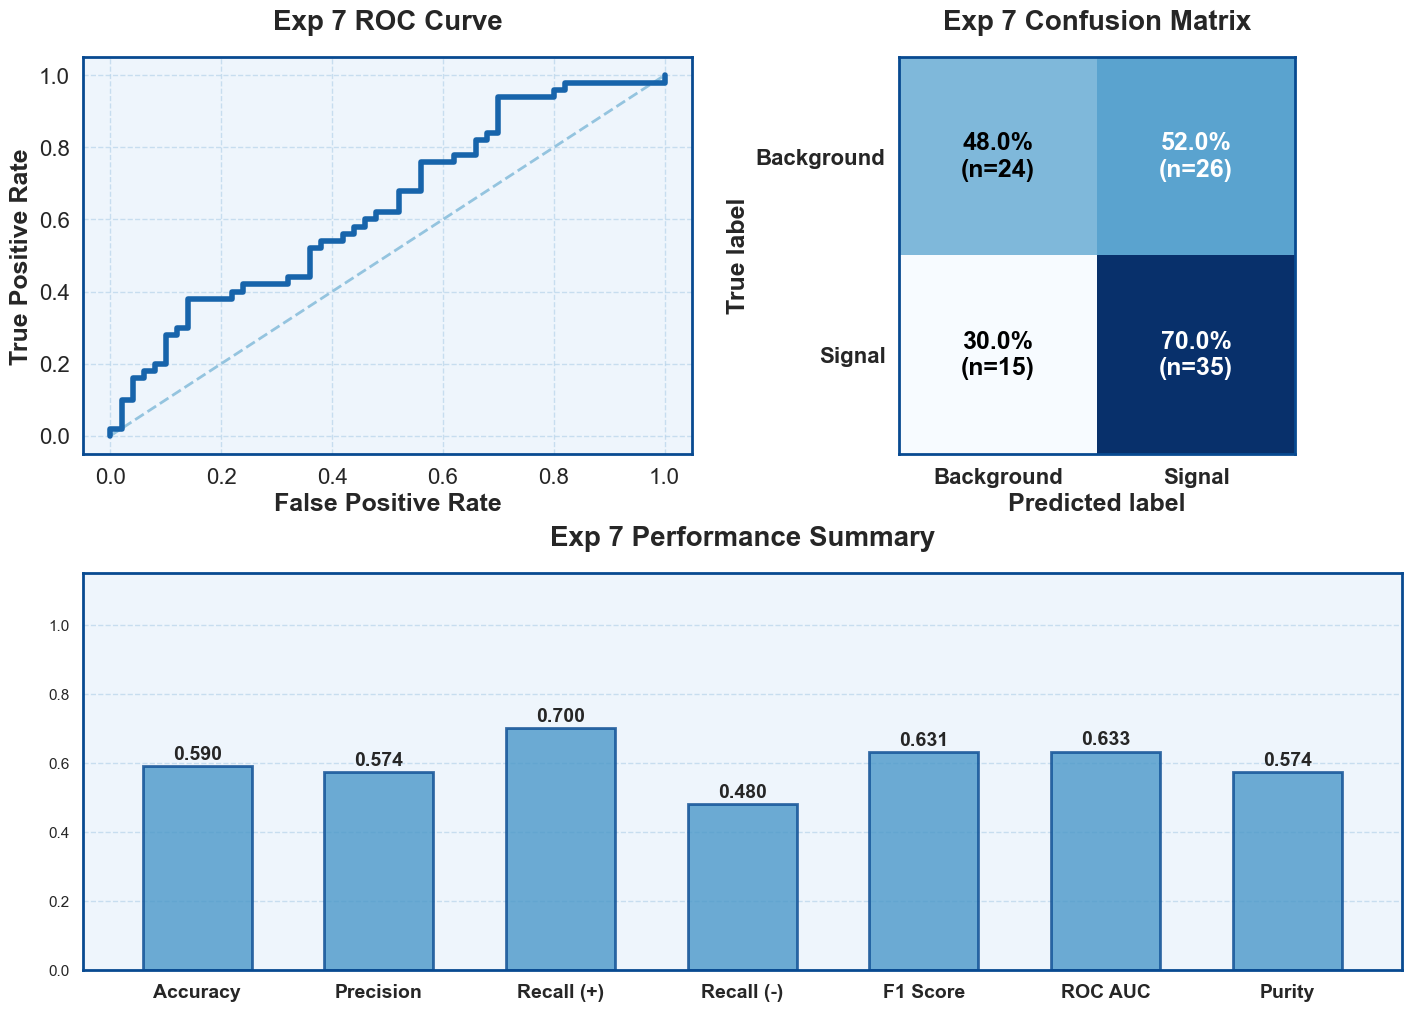

In [23]:
# ========================
# 4.4. QSVC PCA80 (Exp 7)
# ========================

# Configuration: Best sensitivity setup (ZZ + 1 rep)
qsvc_params_04 = {
    "pca_dim": 80, 
    "kernel_name": "ZZFeatureMap",
    "reps": 1,
    "c_param": 1.0
}

# Run experiment
model_q7, metrics_q7, y_pred_q7, y_score_q7, history_q7 = run_experiment(
    X_train_pca80, y_train, X_test_pca80, y_test, 
    model_type="QSVM", force_train=False, **qsvc_params_04
)

# Verification and plot
plot_model_performance(metrics_q7, y_test, y_pred_q7, y_score_q7, title_prefix="Exp 7")

The results for experiment 7 show a unexpected degradation in performance, suggesting that simply increasing the input dimensionality to PCA-80% without a corresponding increase in circuit complexity is insufficient. It appears that a single repetition of the feature map lacks the necessary expressivity to effectively map such a high-dimensional classical space into the quantum Hilbert space, essentially "starving" the model of the structural depth needed to process the added information. These findings directly motivate our final QSVC experiment, which will test if doubling the circuit layers can provide the required expressivity to harness the full potential of the high-variance dataset without further saturating the analysis.

## Experiment 8. Deeper high scale QSVC.

This model represents the final configuration in our QSVC suite, integrating the high-variance PCA-80% dataset with an increased circuit depth of ``reps=2``. This setup aims to resolve the expressivity bottleneck observed in previous iterations, testing whether the synergy between richer input data and a more complex quantum mapping can finally break the classical performance ceiling.

[Cache] Valid experiment found. Loading: QUAN_QSVM_PCA80_C-1_Kern-ZZFeatureMap_CycReps-2


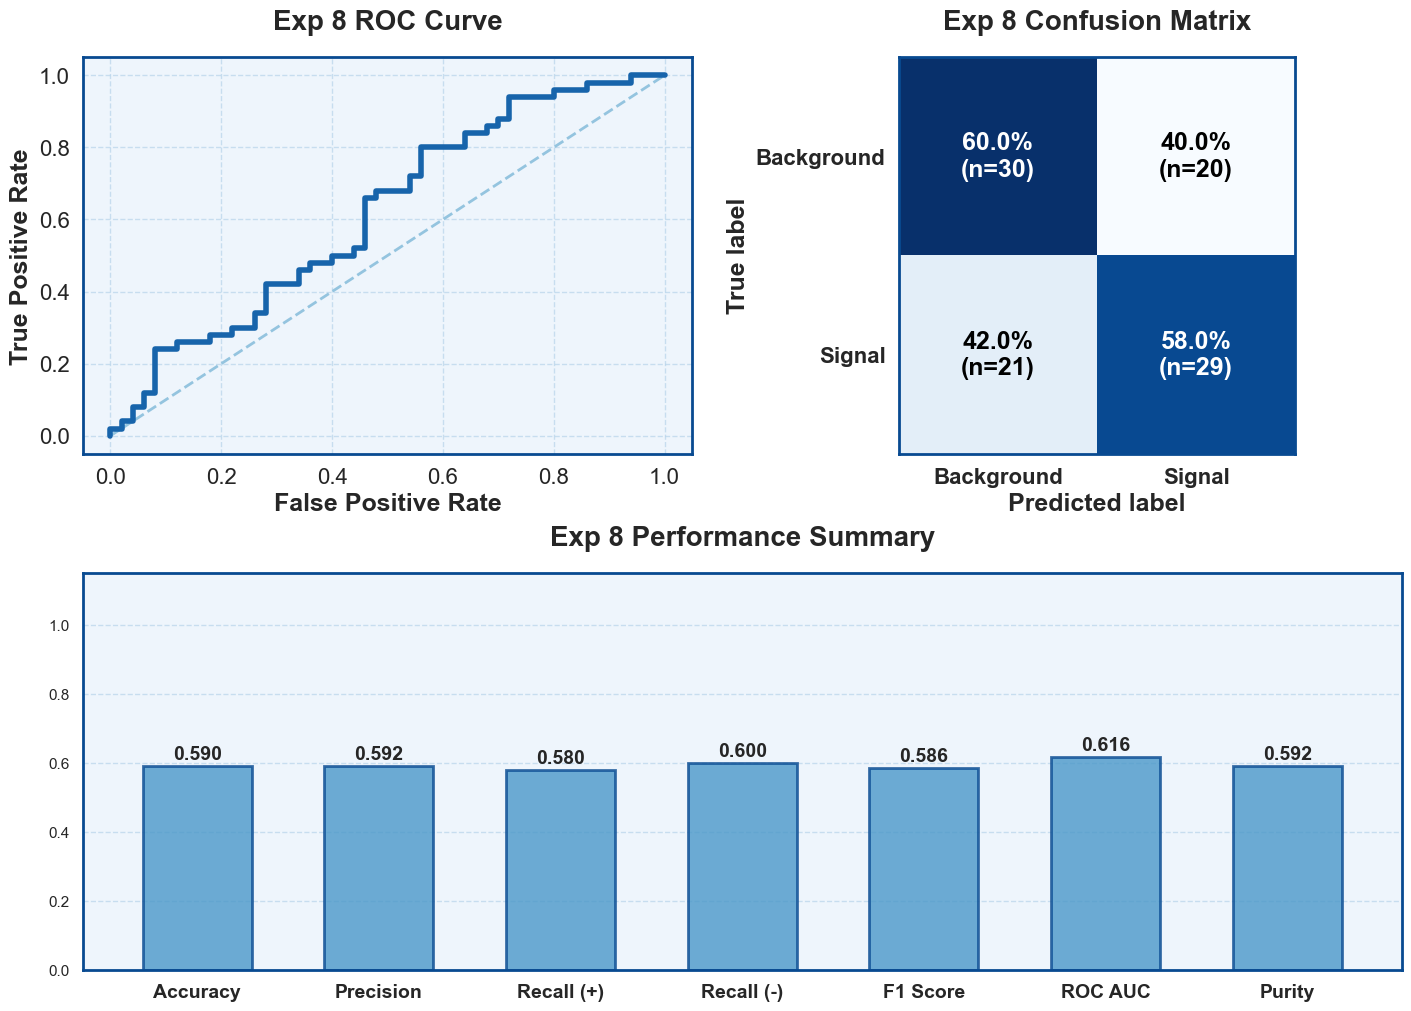

In [24]:
# ================================
# 4.5. QSVC PCA80 & depth (Exp 8)
# ================================

# Configuration: Same as before with one more rep
qsvc_params_05 = {
    "pca_dim": 80, 
    "kernel_name": "ZZFeatureMap",
    "reps": 2,
    "c_param": 1.0
}

# Run experiment
model_q8, metrics_q8, y_pred_q8, y_score_q8, history_q8 = run_experiment(
    X_train_pca80, y_train, X_test_pca80, y_test, 
    model_type="QSVM", force_train=False, **qsvc_params_05
)

# Verification and plot
plot_model_performance(metrics_q8, y_test, y_pred_q8, y_score_q8, title_prefix="Exp 8")

This validate our expressivity hypothesis, as the increased circuit depth successfully improved classification performance compared to the single-layer PCA-80% model. However, the metrics still fall short of the results achieved in experiment 6, suggesting that while higher dimensionality and depth are necessary, **their interplay is non-trivial and may require more sophisticated entanglement or precise hyperparameter tuning**. These findings confirm a clear correlation between circuit capacity and data complexity, providing a strong foundation for further research into optimized quantum feature maps that can more efficiently bridge the gap between high-variance classical inputs and quantum state representation.

# Quantum Neural Networks (QNNs).

In the final phase of our comparative study, we transition from fixed-kernel methods to VQC, which function as quantum-classical hybrid neural networks. These models utilize a parametrized quantum circuit (ansatz) where the rotation angles are optimized during training, similar to the weights in a classical neural network, to minimize a cost function. This section evaluates four distinct architectures designed to test the flexibility of variational circuits in the $t\bar{t}H$ context. We begin with a baseline VQC using a standard ``RealAmplitudes`` ansatz and PCA-3 features to establish a performance floor. This is followed by an Ansatz Complexity model, where we implement the ``EfficientSU2`` circuit to introduce a wider range of single q-bit operations and entangling gates, theoretically increasing the model's ability to represent complex decision boundaries.

To further refine our approach, we explore depth and scale impact configurations. For these two models, extensive preliminary iterations were performed to identify the "sweet spots" where circuit expressivity and data dimensionality are optimally balanced. To maintain a concise and focused narrative within this notebook, we have selected the most representative configuration from each study: one that demonstrates the effect of increasing variational layers on 3 q-bit systems, and another that evaluates the scalability of the VQC when processing the high-variance PCA-80% dataset. These experiments will determine if the adaptability of trained quantum weights can outperform the rigid mapping of the QSVC models previously discussed.

## Experiment 9. QNN baseline.
This model initializes our variational study using a 3 q-bit system paired with a robust ``ZZFeatureMap`` of 3 repetitions to ensure high-dimensional data encoding. This model employs the ``RealAmplitudes`` ansatz with a single layer of trainable parameters, providing a fundamental test of whether a hybrid quantum-classical optimization can effectively adjust its decision boundary for the $t\bar{t}H$ signal. By focusing on a low q-bit regime with limited variational depth, we establish a benchmark for how well the ``COBYLA`` optimizer (or similar) handles the non-convex landscape of the quantum cost function under 100 iterations.

[Storage] Loaded Quantum Weights for 'QUAN_QNN_PCA3_Ans-RealAmplitudes_FM-ZZ_Iter-100_AnsReps-1_FMReps-3'.
[Cache] Valid experiment found. Loading: QUAN_QNN_PCA3_Ans-RealAmplitudes_FM-ZZ_Iter-100_AnsReps-1_FMReps-3


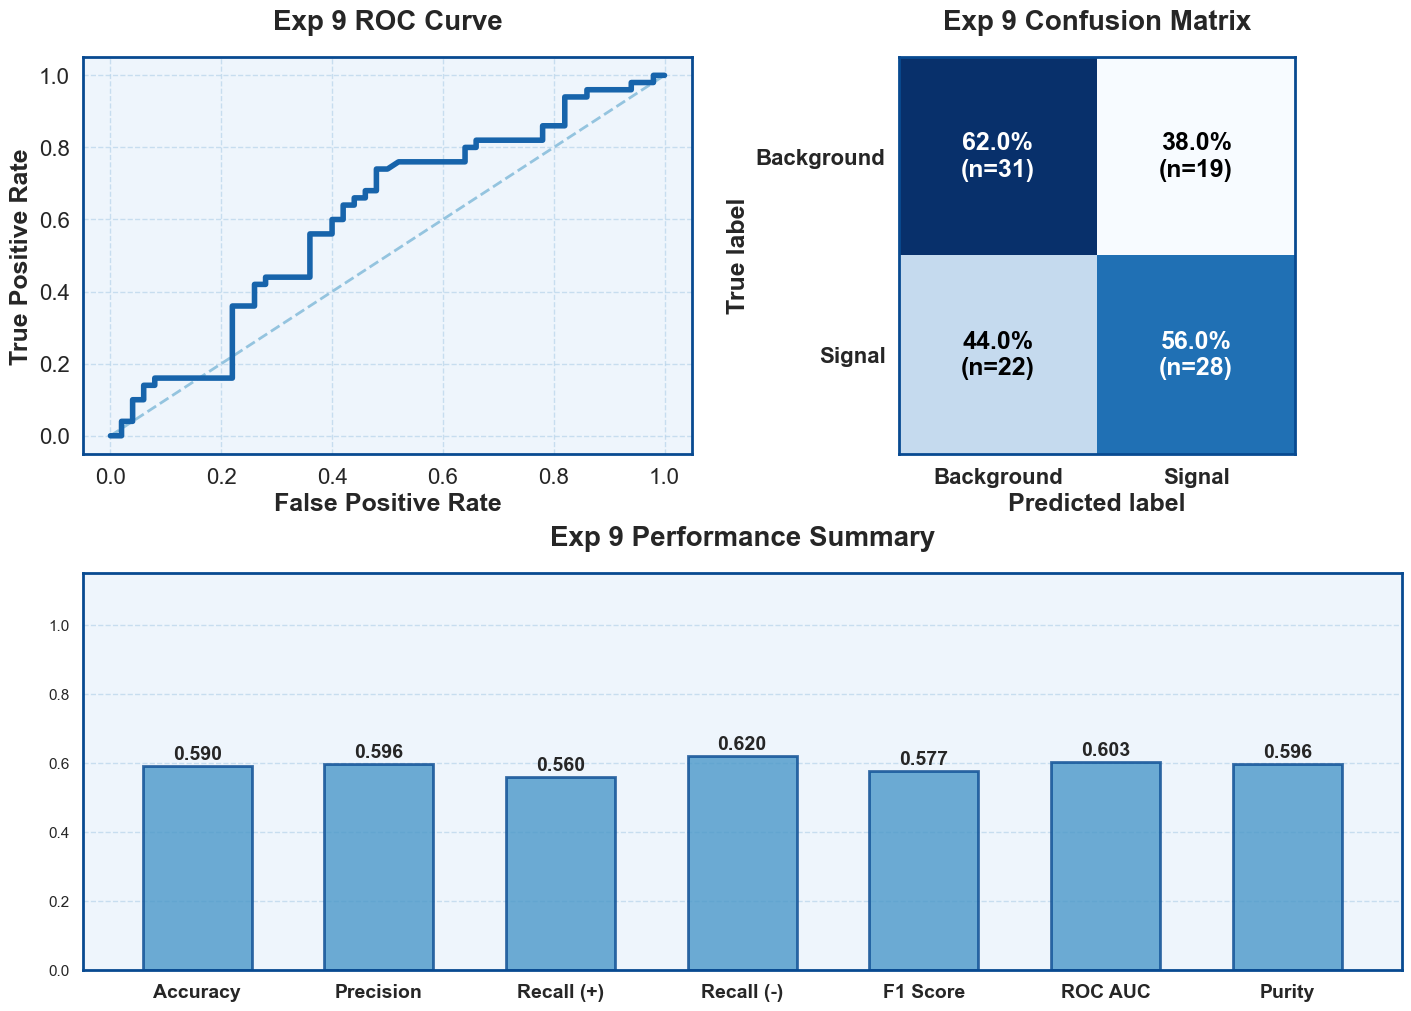

In [25]:
# ==========================
# 5.1. VQC Baseline (Exp 9)
# ==========================

# Baseline QNN: Using the sensitivity dataset (3 q-bits)
vqc_params_01 = {
    "pca_dim": 3,
    "feature_map_type": "ZZ",
    "ansatz_type": "RealAmplitudes",
    "reps_fm": 3,
    "reps_ansatz": 1,
    "max_iter": 100
}

# Run experiment
model_q9, metrics_q9, y_pred_q9, y_score_q9, history_q9 = run_experiment(
    X_train_pca3, y_train, X_test_pca3, y_test, 
    model_type="QNN", force_train=False, **vqc_params_01
)

# Visual analysis
plot_model_performance(
    metrics_q9, y_test, y_pred_q9, y_score_q9, 
    title_prefix="Exp 9"
)

The results from experiment 9 reveal a unique behavior in the VQC baseline: **it achieves the lowest type I error** (false positives) among all models evaluated before. This is a highly significant finding, as background rejection was precisely where the classical architectures reached their performance ceiling. However, despite this specific success in purifying the signal, the model exhibits a lower overall performance across broader metrics compared to previous experiments. This trade-off suggests that while the variational approach is exceptionally adept at identifying background noise, the limited single-layer ansatz might lack the global discriminative power needed to maintain high accuracy and recall simultaneously.

## Experiment 10. Gates impact.

The ``EfficientSU2`` ansatz (experiment 10) introduces a significantly more flexible variational structure by utilizing the ``EfficientSU2`` circuit, which incorporates a broader range of single q-bit rotations (SU(2) gates) and entangling layers. This increase in "gates impact" is designed to enhance the model's non-linear mapping capabilities, allowing the optimizer to explore a more complex parameter space to better capture the intricate physics of the 2lss channel. By maintaining the 3 q-bit PCA-3 input but upgrading the ansatz, we isolate the effect of circuit expressivity on the model's ability to minimize loss during the 100 training iterations.

[Storage] Loaded Quantum Weights for 'QUAN_QNN_PCA3_Ans-EfficientSU2_FM-ZZ_Iter-100_AnsReps-1_FMReps-3'.
[Cache] Valid experiment found. Loading: QUAN_QNN_PCA3_Ans-EfficientSU2_FM-ZZ_Iter-100_AnsReps-1_FMReps-3


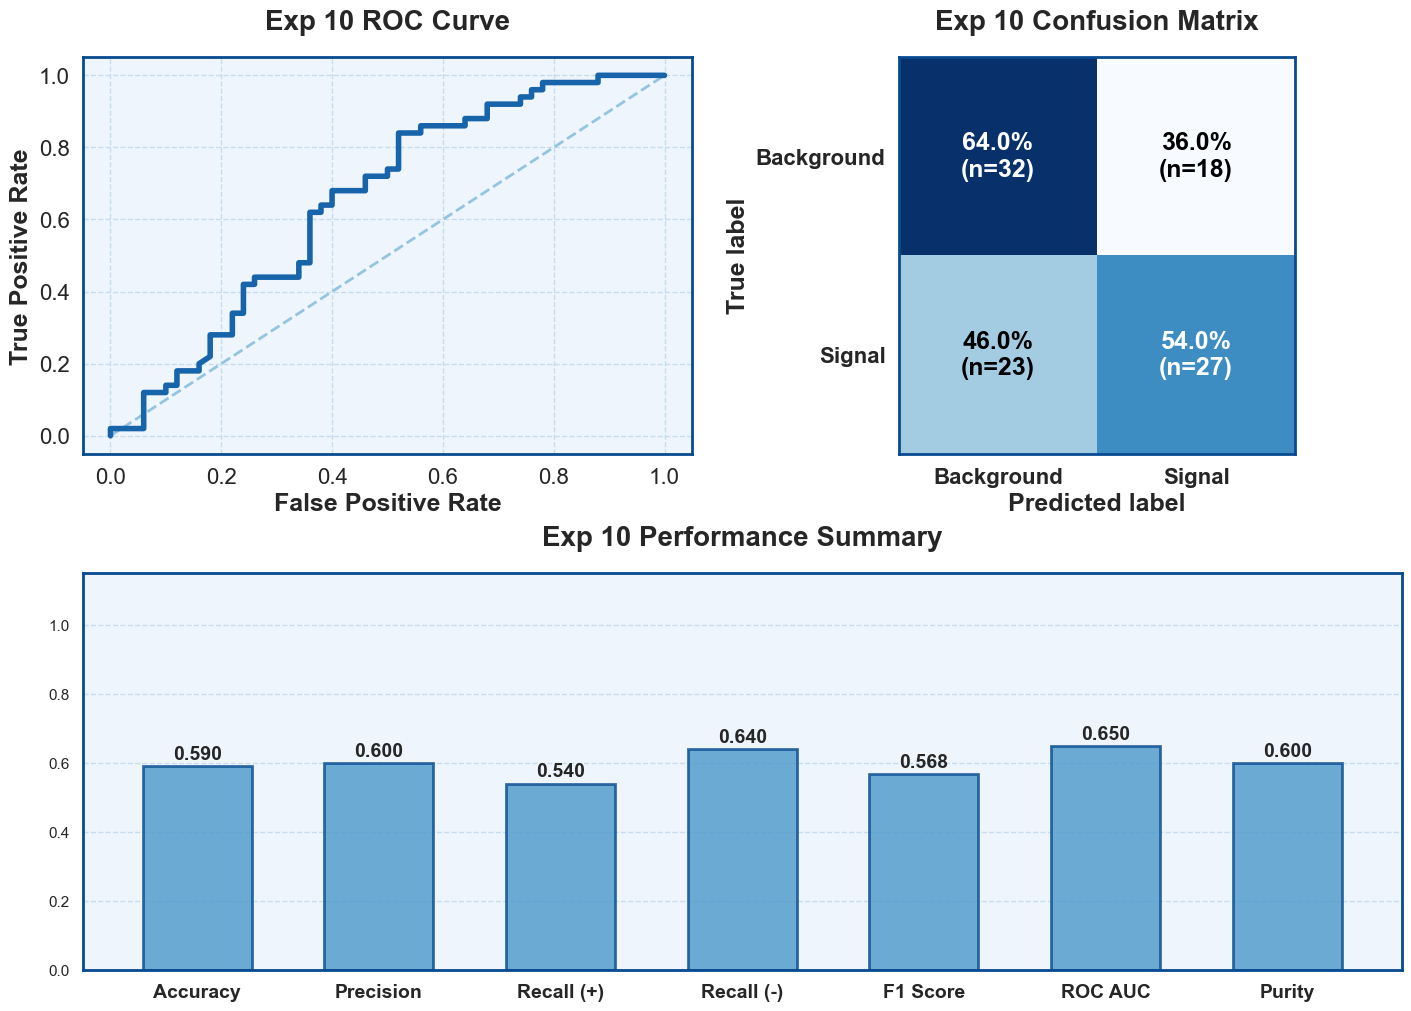

In [26]:
# ===================================
# 5.2. EfficientSU2 Ansatz (Exp 10)
# ===================================

# Testing a more expressive ansatz for better non-linear mapping
vqc_params_02 = {
    "pca_dim": 3,
    "feature_map_type": "ZZ",
    "ansatz_type": "EfficientSU2", # Higher expressivity
    "reps_fm": 3,
    "reps_ansatz": 1,
    "max_iter": 100
}

# Run experiment
model_q10, metrics_q10, y_pred_q10, y_score_q10, history_q10 = run_experiment(
    X_train_pca3, y_train, X_test_pca3, y_test, 
    model_type="QNN", force_train=False, **vqc_params_02
)

# Visual analysis
plot_model_performance(
    metrics_q10, y_test, y_pred_q10, y_score_q10, 
    title_prefix="Exp 10"
)

This results show a improvement over the VQC baseline, although overall performance metrics still trail behind those achieved by the QSVC models. Most significantly, this architecture further minimizes type I error, reinforcing the idea that variational models are particularly effective at reducing false positives. This trend is highly promising for signal purification, suggesting that while fixed kernels currently offer better global accuracy, the trainable SU2 gates provide a specialized precision in background rejection that classical methods struggled to reach.

## Experiment 11. Depth impact.

This model explores the impact of increasing the number of trainable parameters by doubling the ``EfficientSU2`` ansatz repetitions and extending the optimization limit to 150 iterations. This configuration is the result of multiple preliminary tests exploring different combinations of feature map and ansatz depths; we identified this specific setup as the "sweet spot" for balancing expressivity and training stability. However, the results confirm a recurring constraint observed in our quantum study: with only 3 q-bits, excessive repetitions fail to provide additional value and can even degrade performance, as the circuit begins to over-parameterize a very limited information space.

[Storage] Loaded Quantum Weights for 'QUAN_QNN_PCA3_Ans-EfficientSU2_FM-ZZ_Iter-150_AnsReps-2_FMReps-3'.
[Cache] Valid experiment found. Loading: QUAN_QNN_PCA3_Ans-EfficientSU2_FM-ZZ_Iter-150_AnsReps-2_FMReps-3


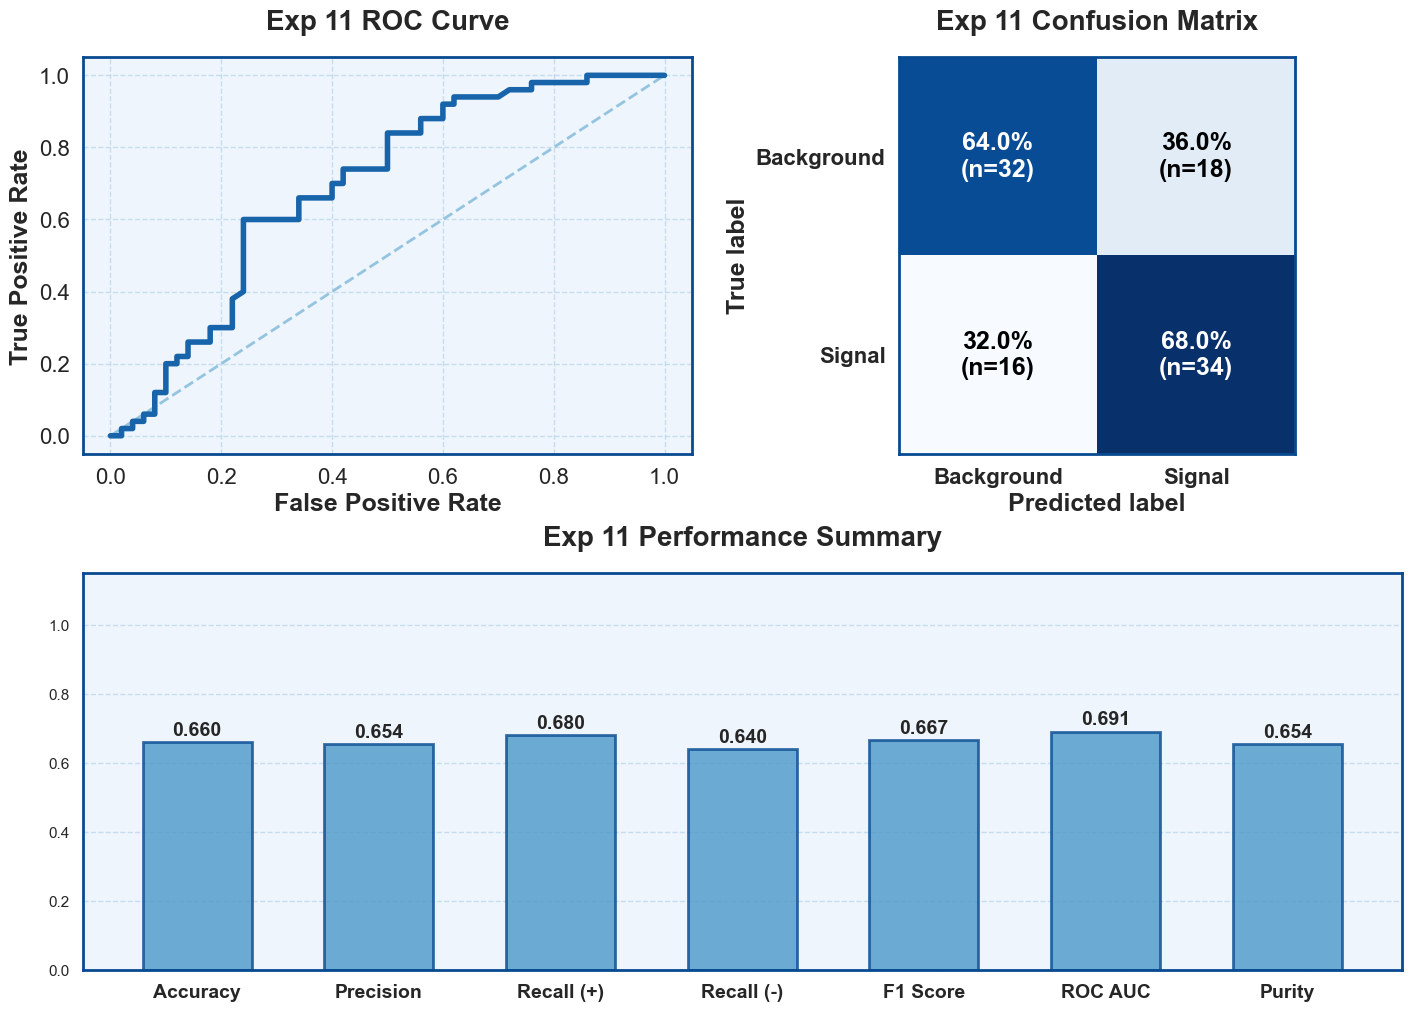

In [27]:
# =======================
# 5.3. "Deep" QNN (Exp 11)
# =======================

# Exploring depth: More repetitions in the Ansatz to increase 
# the number of trainable parameters.
vqc_params_03 = {
    "pca_dim": 3,
    "feature_map_type": "ZZ",
    "ansatz_type": "EfficientSU2",
    "reps_fm": 3,       # Keep data encoding depth
    "reps_ansatz": 2,   # Doubling the trainable layers
    "max_iter": 150     # Increasing iterations as there are more parameters to optimize
}

# Run experiment
model_q11, metrics_q11, y_pred_q11, y_score_q11, history_q11 = run_experiment(
    X_train_pca3, y_train, X_test_pca3, y_test, 
    model_type="QNN", force_train=False, **vqc_params_03
)

# Visual analysis
plot_model_performance(
    metrics_q11, y_test, y_pred_q11, y_score_q11, 
    title_prefix="Exp 11"
)

The results from model 11 show a significant performance improvement while maintaining the characteristic minimum in type I error observed in previous VQC iterations. This synergy suggests that finding the optimal balance between circuit depth and training iterations allows the variational model to refine its classification power without sacrificing its superior background rejection capabilities. These findings are highly promising, as they indicate that the VQC architecture is finally maturing, setting a high benchmark for our final experiment where we will test if this optimized "deep" configuration can successfully scale to handle the high-variance PCA-80% dataset.

## Experiment 12. Scale impact.

This model concludes our research by evaluating how the variational architecture responds to a high-density information environment using the PCA-80% dataset. By expanding the input layer and increasing the optimization budget to 200 iterations, this model aims to determine if the VQC can effectively process the broader variance of the $t\bar{t}H$ signal when provided with a more complex feature space. This final test is crucial for understanding whether the adaptability of a trained ansatz can overcome the performance plateaus encountered in previous low-dimensional experiments.

[Storage] Loaded Quantum Weights for 'QUAN_QNN_PCA9_Ans-EfficientSU2_FM-ZZ_Iter-200_AnsReps-2_FMReps-3'.
[Cache] Valid experiment found. Loading: QUAN_QNN_PCA9_Ans-EfficientSU2_FM-ZZ_Iter-200_AnsReps-2_FMReps-3


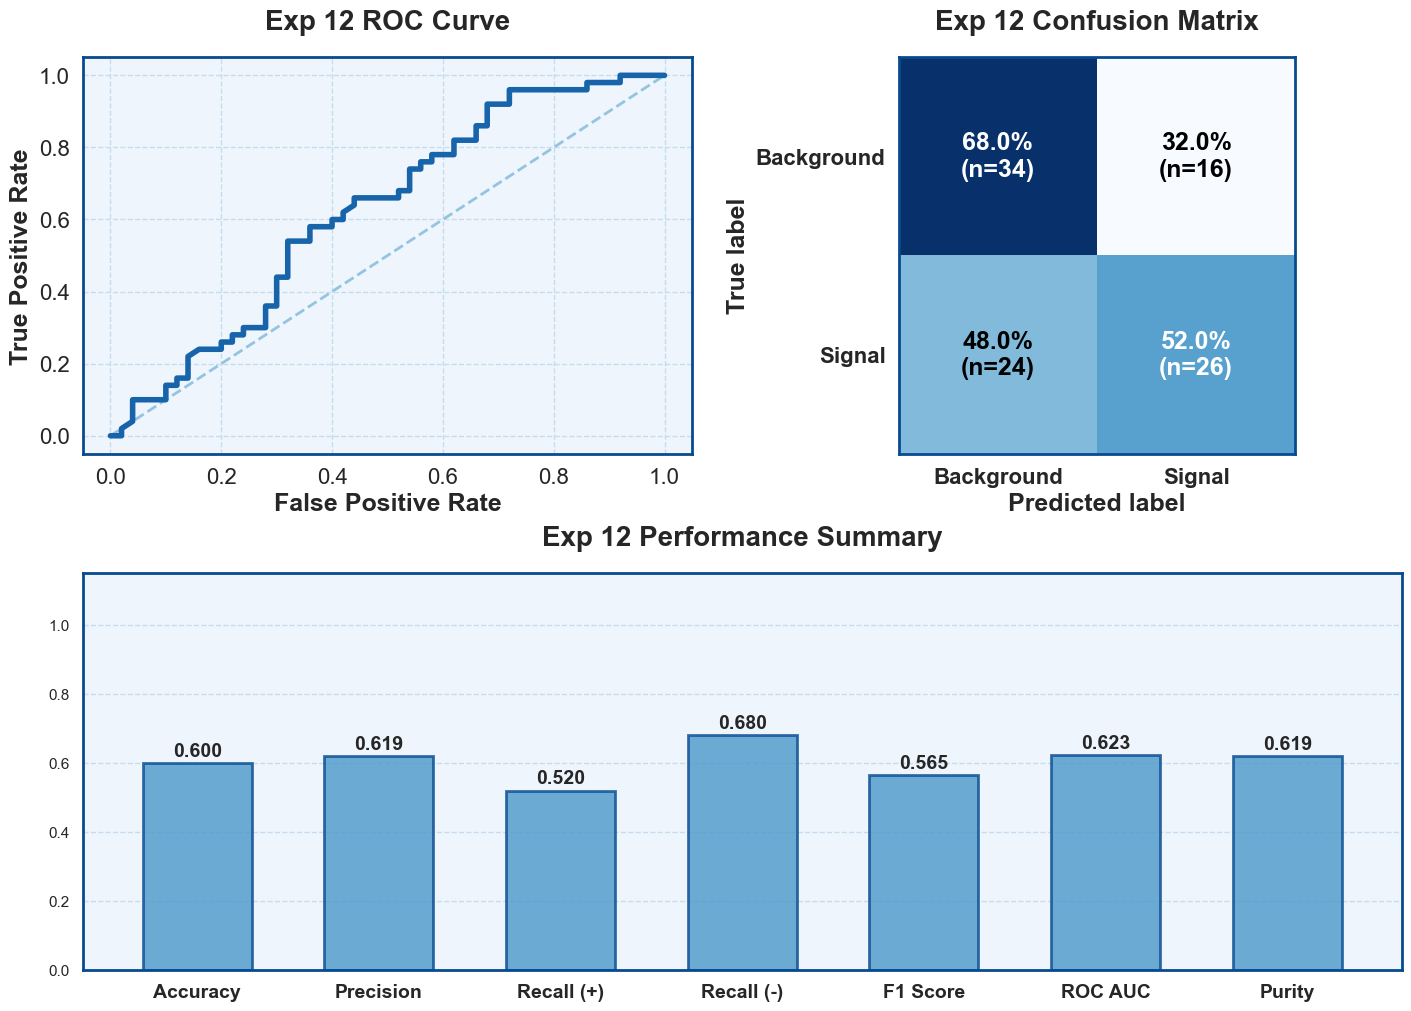

In [28]:
# ==========================
# 6.1. Scale Study (Exp 12)
# ==========================

vqc_params_scale = {
    "pca_dim": X_train_pca80.shape[1], 
    "feature_map_type": "ZZ",
    "ansatz_type": "EfficientSU2",
    "reps_fm": 3,       
    "reps_ansatz": 2,
    "max_iter": 200
}

# Run experiment
model_q12, metrics_q12, y_pred_q12, y_score_q12, history_q12 = run_experiment(
    X_train_pca80, y_train, X_test_pca80, y_test, 
    model_type="QNN", force_train=False, **vqc_params_scale
)

# Visual analysis
plot_model_performance(
    metrics_q12, y_test, y_pred_q12, y_score_q12, 
    title_prefix=f"Exp 12"
)

These final results demonstrate that the VQC further minimizes type I error when processing the PCA-80% dataset, reaching the highest precision in background exclusion of the entire study. However, this comes at the cost of a higher type II error, indicating that the model becomes overly conservative in its signal identification as the dimensionality increases. This trade-off suggests that while a higher q-bit count provides a richer information landscape, the current depth configuration may not be fully optimized for such high-dimensional spaces. Although various entanglement strategies were explored—including full and circular topologies, which yielded slightly inferior results compared to the default linear entanglement used here—the findings highlight that future research should focus on more sophisticated circuit structures to regain sensitivity without losing this exceptional precision.

# Final conclusions and further research.

The final section of this study provides a comprehensive performance matrix that consolidates the results from all 12 experiments, ranging from classical benchmarks to advanced variational quantum architectures. This comparative analysis serves to identify the "sweet spots" where quantum models begin to rival or exceed classical performance, specifically highlighting how different encoding strategies and circuit depths impact the model's ability to distinguish the $t\bar{t}H$ signal from background noise. By **sorting the results by F1-Score**, we can objectively rank each approach's balanced classification capability, while the highlighted purity and recall columns reveal the specific strengths of quantum models in background rejection.

This synthesis not only quantifies the trade-offs between computational time and accuracy but also provides a clear roadmap for the future integration of QML in HEP. The data demonstrates that while classical models maintain high global efficiency, the quantum classifiers—particularly the VQC family—introduce a specialized precision that is crucial for rare event searches. This final ranking is intended to move beyond individual metrics and offer a holistic view of the current state of quantum-classical hybrid systems in the context of the LHC's most challenging datasets.

In [29]:
# ====================================
# 6. Final Model Comparison & Ranking
# ====================================

# Dictionary consolidating all experiments (Classical & Quantum)
metrics_dicts = {
    'Exp 1 (SVM optimized)': metrics1,
    'Exp 2 (deep NN)': metrics2,
    'Exp 3 (shallow NN)': metrics3,
    'Exp 4 (QSVC Z-Map)': metrics_q4,
    'Exp 5 (QSVC ZZ-Map)': metrics_q5,
    'Exp 6 (QSVC depth impact)': metrics_q6,
    'Exp 7 (QSVC PCA80 impact)': metrics_q7,
    'Exp 8 (QSVC PCA80 & Depth)': metrics_q8,
    'Exp 9 (VQC baseline)': metrics_q9,
    'Exp 10 (VQC EfficientSU2)': metrics_q10,
    'Exp 11 (VQC deep QNN)': metrics_q11,
    'Exp 12 (VQC scale study 80%)': metrics_q12
}

rows = []
for name, metrics in metrics_dicts.items():
    if metrics is not None:
        # Conversion from seconds to minutes
        training_time_min = metrics.get('training_time_sec', 0) / 60
        
        rows.append({
            'Model': name,
            'Accuracy': metrics.get('accuracy'),
            'F1-Score': metrics.get('f1'),
            'ROC AUC': metrics.get('roc_auc'),
            'Precision': metrics.get('precision'),
            'Recall (+)': metrics.get('recall_positive'),
            'Recall (-)': metrics.get('recall_negative'),
            'Purity': metrics.get('purity'),
            'Time (min)': round(training_time_min, 2)
        })

# Create DataFrame
df_comparison = pd.DataFrame(rows)

# Sorting by F1-Score as requested
df_comparison = df_comparison.sort_values('F1-Score', ascending=False).reset_index(drop=True)

# Styling with 'Blues' cmap on specific performance metrics
styled_df = df_comparison.style.background_gradient(
    cmap='Blues', 
    subset=['F1-Score', 'Purity', 'Recall (+)']
).format({
    'Time (min)': "{:.2f}",
    'Accuracy': "{:.4f}",
    'F1-Score': "{:.4f}",
    'ROC AUC': "{:.4f}",
    'Precision (Purity)': "{:.4f}",
    'Recall (Sensitivity)': "{:.4f}"
})

# Display the performance matrix
display(styled_df)

,Model,Accuracy,F1-Score,ROC AUC,Precision,Recall (+),Recall (-),Purity,Time (min)
0,Exp 5 (QSVC ZZ-Map),0.7100,0.7680,0.7060,0.640000,0.960000,0.460000,0.640000,19.65
1,Exp 4 (QSVC Z-Map),0.7000,0.7581,0.6828,0.635135,0.940000,0.460000,0.635135,18.15
2,Exp 2 (deep NN),0.7100,0.7563,0.7492,0.652174,0.900000,0.520000,0.652174,0.11
3,Exp 1 (SVM optimized),0.7000,0.7500,0.7484,0.642857,0.900000,0.500000,0.642857,0.33
4,Exp 3 (shallow NN),0.7100,0.7478,0.7372,0.661538,0.860000,0.560000,0.661538,0.15
5,Exp 6 (QSVC depth impact),0.6900,0.7207,0.6852,0.655738,0.800000,0.580000,0.655738,22.49
6,Exp 11 (VQC deep QNN),0.6600,0.6667,0.6908,0.653846,0.680000,0.640000,0.653846,10.34
7,Exp 7 (QSVC PCA80 impact),0.5900,0.6306,0.6328,0.573770,0.700000,0.480000,0.573770,44.50
8,Exp 8 (QSVC PCA80 & Depth),0.5900,0.5859,0.6164,0.591837,0.580000,0.600000,0.591837,56.76
9,Exp 9 (VQC baseline),0.5900,0.5773,0.6034,0.595745,0.560000,0.620000,0.595745,4.40


The analysis of the $t\bar{t}H$ (2lss) channel through various machine learning lenses reveals a complex landscape where classical efficiency meets quantum precision. To handle the raw data, we applied critical preprocessing steps including ``StandardScaler`` normalization to homogenize the different kinematic scales and PCA. PCA proved to be a double-edged sword: while it enabled the execution of quantum circuits on 3 q-bits by compressing information into the highest-variance components, the results from experiment 7 and 12 suggest that high-density data (PCA-80%) requires a significant increase in circuit expressivity to be fully exploited.

The experimental results show that **the QSVC with ZZ-FeatureMap (exp 5) achieved the best overall performance** with an F1-Score of 0.7680, slightly outperforming both the optimized deep Neural Network (NN) and the SVM. However, this superior performance comes with a massive computational cost; while classical models trained in fractions of a second, the (simulated) QSVC required nearly 20 minutes for a similar task. The VQC models, despite having lower global F1-scores, demonstrated a unique advantage in precision and background rejection (recall -), with experiment 12 reaching the highest purity (0.6190) and background recall (0.6800). This suggests that variational models are more "conservative" and precise, making them ideal candidates for signal purification in rare event searches, even if they currently struggle with higher type II errors.

In terms of complexity, the VQC models involved the most challenging hyperparameterization, requiring a delicate balance between feature map repetitions, ansatz types (``RealAmplitudes`` vs. ``EfficientSU2``), and optimization iterations. The classical models are clearly superior in time performance and ease of deployment, but they lack the specific "signal-cleaning" capability observed in the quantum variational circuits.

Moving forward, the results suggest several promising avenues for future investigation:

- **Dynamic entanglement**. Since linear entanglement provided better results than circular or full topologies, further research into adaptive entanglement layers could help the VQC better capture variable correlations.

- **Kernel-ansatz synergy**. Investigating the mathematical mapping between the feature map and the ansatz to avoid the "bottlenecks" seen in experiment 11, where added depth didn't translate to better accuracy.

- **Hybrid ensembles**. Developing ensemble methods that combine the high sensitivity (Recall) of classical Random Forests with the high purity of VQCs to create a more robust classifier for the LHC.